# NTK Eigenspace Alignment and Reliability on $S^1$

This notebook extends the original eigenspace-alignment analysis with a reliability layer based on Fourier-block perturbations and target-dependent metrics.

Let $A = K/n$ be the normalized empirical frozen NTK operator on an equally spaced circle grid, and let $\Phi$ be the real Fourier basis up to frequency $K_{max}$.
For each frequency $k$:

- $F_0 = \mathrm{span}\{1\}$ (dimension 1),
- $F_k = \mathrm{span}\{\sqrt{2}\cos(k\theta), \sqrt{2}\sin(k\theta)\}$ for $k\ge 1$ (dimension 2).

With orthonormal Fourier frame $U_k$ and matched empirical frame $\hat U_k$, we compare projectors

$$P_k = U_kU_k^\top, \qquad \hat P_k = \hat U_k \hat U_k^\top,$$

instead of individual eigenvectors, because signs/rotations inside 2D eigenspaces are not identifiable.

Part A focuses on these subspace objects (projectors, angles, eigenvalue alignment). Part B adds block/action objects
$B_m^{(K)}=(1/n)\Phi^\top A\Phi$ and $B_m^{(K)}-\Lambda_K$ to analyze when frozen Fourier-mode predictions are reliable for each target support.


## Experiment Setup

- Domain: equally spaced grid $\theta_i = 2\pi i/n$, embedded as $x(\theta)=(\cos\theta,\sin\theta)$.
- Model: one-hidden-layer ReLU network in NTK parameterization, frozen at initialization.
- Sweep: multiple widths and seeds.
- Operator: $A=K/n$ from empirical NTK matrix $K$.
- Fourier basis: real basis up to configured $K_{max}$ with metadata `(mode_names, mode_freqs, mode_types)`.

For each frequency $k$, we build matched empirical eigenspaces and track:

- projector distances $\|\hat P_k-P_k\|_F$ and $\|\hat P_k-P_k\|_{op}$,
- principal angles between $F_k$ and $\hat F_k$,
- center eigenvalue error and pair splitting.

For the reliability extension we additionally track:

- block perturbation norms of $B_m^{(K)}-\Lambda_K$,
- frequency leakage (off-block vs on-block action),
- target-level action error and worst-case support ratio.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils.artifacts_io import latest_run_dir, load_manifest, npz

BASE = Path('../results')
EXP_NAME = 'ntk_eigenspace_alignment_on_S1'
PLOT_DIR = Path('plots') / EXP_NAME
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

print('Plots will be saved to:', PLOT_DIR)

Plots will be saved to: plots/ntk_eigenspace_alignment_on_S1


In [2]:
run_dir = latest_run_dir(BASE, EXP_NAME)
if run_dir is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME}' in {BASE}")

manifest = load_manifest(run_dir)
summary = npz(run_dir, manifest['summary'])
basis = npz(run_dir, manifest['basis_metadata'])
probe = npz(run_dir, manifest['probe_geometry'])

if not bool(manifest.get('meta', {}).get('save_aligned_eigvecs', False)):
    raise RuntimeError(
        'This notebook now assumes new runs with artifacts.save_aligned_eigvecs=true.'
    )

required_cumulative = [
    'cumulative_cutoffs',
    'cumulative_dims',
    'cumulative_projector_fro_mean',
    'cumulative_projector_fro_std',
    'cumulative_projector_op_mean',
    'cumulative_projector_op_std',
    'cumulative_affinity_rms_mean',
    'cumulative_affinity_rms_std',
]
missing_cumulative = [k for k in required_cumulative if k not in summary]
if missing_cumulative:
    raise RuntimeError(
        'Missing cumulative summary keys: '
        f"{missing_cumulative}. Rerun experiments/ntk_eigenspace_alignment_on_S1.py with the latest script."
    )

theta = np.asarray(probe['theta'], dtype=float)
n_points = int(manifest['meta']['n_points'])

widths = np.asarray(summary['widths'], dtype=int)
frequencies = np.asarray(summary['frequencies'], dtype=int)
projector_fro_mean = np.asarray(summary['projector_fro_mean'], dtype=float)
projector_fro_std = np.asarray(summary['projector_fro_std'], dtype=float)
projector_op_mean = np.asarray(summary['projector_op_mean'], dtype=float)
projector_op_std = np.asarray(summary['projector_op_std'], dtype=float)
principal_angles_mean = np.asarray(summary['principal_angles_mean'], dtype=float)
principal_angles_std = np.asarray(summary['principal_angles_std'], dtype=float)
eig_abs_error_mean = np.asarray(summary['eig_abs_error_mean'], dtype=float)
eig_abs_error_std = np.asarray(summary['eig_abs_error_std'], dtype=float)
pair_splitting_mean = np.asarray(summary['pair_splitting_mean'], dtype=float)
pair_splitting_std = np.asarray(summary['pair_splitting_std'], dtype=float)
lambda_theory = np.asarray(summary['lambda_theory'], dtype=float)
min_width_for_small_error = np.asarray(summary['min_width_for_small_error'], dtype=int)
failing_freqs_at_max_width = np.asarray(summary['failing_freqs_at_max_width'], dtype=int)
projector_fro_tol = float(np.ravel(summary['projector_fro_tol'])[0])

cumulative_cutoffs = np.asarray(summary['cumulative_cutoffs'], dtype=int)
cumulative_dims = np.asarray(summary['cumulative_dims'], dtype=int)
cumulative_projector_fro_mean = np.asarray(summary['cumulative_projector_fro_mean'], dtype=float)
cumulative_projector_fro_std = np.asarray(summary['cumulative_projector_fro_std'], dtype=float)
cumulative_projector_op_mean = np.asarray(summary['cumulative_projector_op_mean'], dtype=float)
cumulative_projector_op_std = np.asarray(summary['cumulative_projector_op_std'], dtype=float)
cumulative_affinity_rms_mean = np.asarray(summary['cumulative_affinity_rms_mean'], dtype=float)
cumulative_affinity_rms_std = np.asarray(summary['cumulative_affinity_rms_std'], dtype=float)

if 'min_width_for_small_cumulative_error' in summary:
    min_width_for_small_cumulative_error = np.asarray(
        summary['min_width_for_small_cumulative_error'],
        dtype=int,
    )
else:
    min_width_for_small_cumulative_error = np.full_like(cumulative_cutoffs, -1)

mode_names = basis.get('mode_names')

print('Loaded run dir:', run_dir)
print('n_points:', n_points)
print('widths:', widths.tolist())
print('frequencies:', frequencies.tolist())
print('cumulative cutoffs:', cumulative_cutoffs.tolist())
print('projector_fro_tol:', projector_fro_tol)


Loaded run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/ntk_eigenspace_alignment_on_S1/20260506-165102-25a0cb0b
n_points: 2048
widths: [32, 64, 128, 256, 512, 1024]
frequencies: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
cumulative cutoffs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
projector_fro_tol: 0.25


In [3]:
def fidx(k: int) -> int:
    matches = np.where(frequencies == int(k))[0]
    if len(matches) == 0:
        raise ValueError(f'Frequency {k} not in run frequencies {frequencies.tolist()}')
    return int(matches[0])


def cidx(k: int) -> int:
    matches = np.where(cumulative_cutoffs == int(k))[0]
    if len(matches) == 0:
        raise ValueError(
            f'Cutoff {k} not in cumulative cutoffs {cumulative_cutoffs.tolist()}'
        )
    return int(matches[0])


def widx(w: int) -> int:
    matches = np.where(widths == int(w))[0]
    if len(matches) == 0:
        raise ValueError(f'Width {w} not in run widths {widths.tolist()}')
    return int(matches[0])


def keep_existing(items, allowed):
    allowed = set(allowed)
    return [x for x in items if x in allowed]


def fourier_frame(theta, k: int):
    k = int(k)
    theta = np.asarray(theta, dtype=float)

    if k == 0:
        F = np.ones((len(theta), 1), dtype=float)
        labels = [r'$\phi_0(\theta)=1$']
    else:
        F = np.stack([
            np.sqrt(2.0) * np.cos(k * theta),
            np.sqrt(2.0) * np.sin(k * theta),
        ], axis=1)
        labels = [rf'$\sqrt{{2}}\cos({k}\theta)$', rf'$\sqrt{{2}}\sin({k}\theta)$']

    F = F / (np.linalg.norm(F, axis=0, keepdims=True) + 1e-12)
    F, _ = np.linalg.qr(F)
    return F.astype(np.float32), labels


_width_run_cache = {}
_multi_seed_cache = {}


def get_width_run(width: int):
    width = int(width)
    if width not in _width_run_cache:
        run = npz(run_dir, manifest['runs'][str(width)])
        required = ['aligned_eigvecs', 'fourier_coeffs_raw', 'fourier_coeffs_aligned']
        missing = [k for k in required if k not in run]
        if missing:
            raise RuntimeError(
                f'Run file for width={width} is missing keys {missing}. '
                'Please rerun experiment with the latest script and artifacts.save_aligned_eigvecs=true.'
            )
        _width_run_cache[width] = run
    return _width_run_cache[width]


def aligned_components_across_seeds(width: int, k: int, seeds=None):
    width = int(width)
    k = int(k)

    run = get_width_run(width)
    run_seeds = np.asarray(run['seeds'], dtype=int)
    run_freqs = np.asarray(run['frequencies'], dtype=int)

    f_matches = np.where(run_freqs == k)[0]
    if len(f_matches) != 1:
        raise ValueError(f'Frequency {k} not found in run frequencies {run_freqs.tolist()}')
    f_idx = int(f_matches[0])

    if seeds is None:
        seeds = run_seeds
    seeds = np.asarray(seeds, dtype=int)

    cache_key = (width, k, tuple(seeds.tolist()))
    if cache_key in _multi_seed_cache:
        return _multi_seed_cache[cache_key]

    seed_indices = []
    for s in seeds:
        matches = np.where(run_seeds == int(s))[0]
        if len(matches) != 1:
            raise ValueError(f'Seed {int(s)} not found for width {width}; available {run_seeds.tolist()}')
        seed_indices.append(int(matches[0]))

    seed_indices = np.asarray(seed_indices, dtype=int)

    F, labels = fourier_frame(theta, k)
    d = F.shape[1]

    aligned_all = np.asarray(run['aligned_eigvecs'], dtype=np.float32)
    aligned = aligned_all[seed_indices, f_idx, :d, :]
    mean = np.mean(aligned, axis=0)
    std = np.std(aligned, axis=0)

    coeff_raw_all = np.asarray(run['fourier_coeffs_raw'], dtype=np.float32)
    coeff_aligned_all = np.asarray(run['fourier_coeffs_aligned'], dtype=np.float32)
    coeff_raw = coeff_raw_all[seed_indices, f_idx, :d, :d]
    coeff_aligned = coeff_aligned_all[seed_indices, f_idx, :d, :d]

    eig_idx_all = np.asarray(run['selected_eig_indices'], dtype=int)
    eigvals_all = np.asarray(run['selected_eigvals'], dtype=np.float32)
    eig_idx = eig_idx_all[seed_indices, f_idx, :d]
    eigvals = eigvals_all[seed_indices, f_idx, :d]

    out = {
        'width': width,
        'k': k,
        'seeds': seeds,
        'F': F,
        'labels': labels,
        'd': d,
        'aligned': aligned,
        'mean': mean,
        'std': std,
        'coeff_raw': coeff_raw,
        'coeff_aligned': coeff_aligned,
        'eig_idx': eig_idx,
        'eigvals': eigvals,
        'source': 'saved',
    }

    _multi_seed_cache[cache_key] = out
    return out


## A1) Visual Check: NTK Eigenvectors vs Fourier Waves

Let $U_k$ be an orthonormal Fourier frame and $V_k$ be the selected empirical eigenvectors for frequency $k$.
Raw overlap matrix:

$$M_{raw}=V_k^\top U_k.$$

- Each row gives one empirical eigenvector in Fourier-plane coordinates.
- If subspaces align but bases are rotated, $M_{raw}$ looks like a rotation/mix rather than identity.

Alignment uses orthogonal Procrustes:

$$R = \arg\min_{Q\in O(d)}\|V_kQ-U_k\|_F, \qquad V_k^{align}=V_kR,$$

and then

$$M_{align}=(V_k^{align})^\top U_k.$$

Raw plots show orientation/mixing; aligned plots isolate subspace agreement.


Inspecting width=256, seed=0, k=2
selected empirical eigenvalue indices: [4, 3]
selected empirical eigenvalues: [0.09235960245132446, 0.09619487076997757]
projector_fro=1.7170e-01, projector_op=9.9181e-02
principal angles (deg): [4.015370029081177, 5.691991078796193]
M_raw = V^T U:
 [[-0.97007287 -0.22874314]
 [-0.22627372  0.9698945 ]]
M_align = (V_align)^T U:
 [[0.99611104 0.00122266]
 [0.00122217 0.99650127]]
Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_shape_single_seed_w256_seed0_k2.png


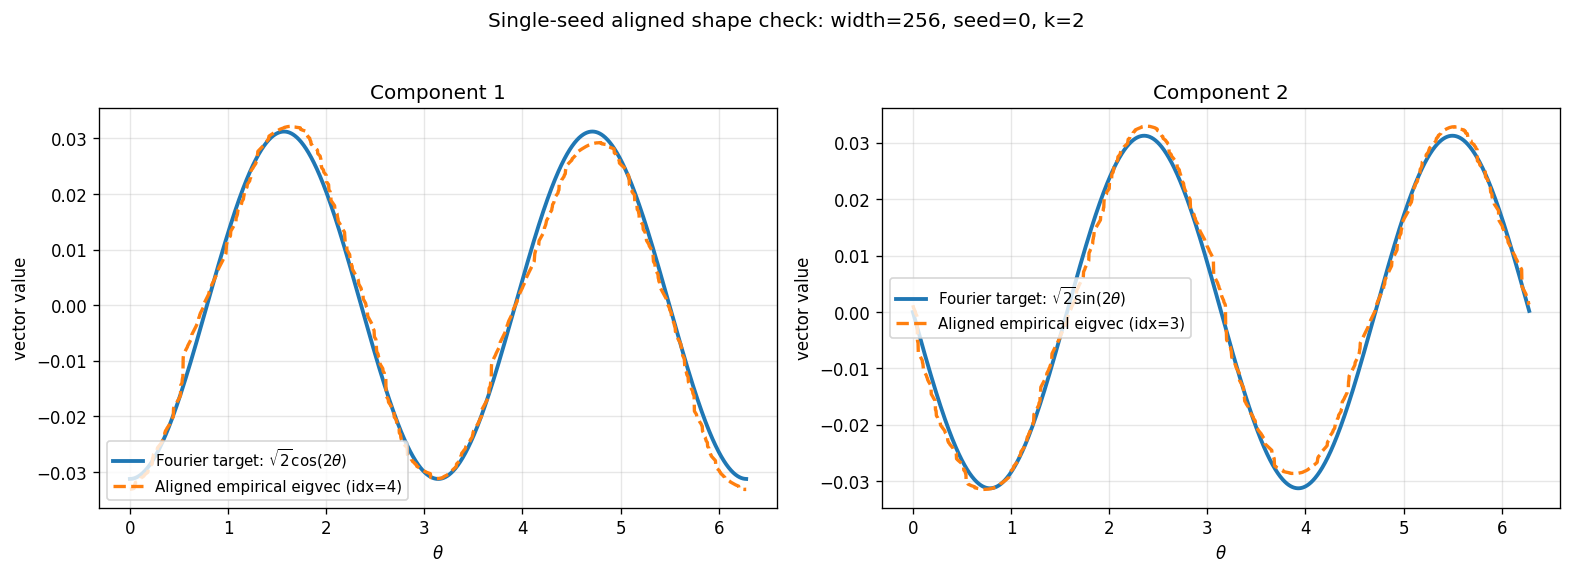

In [4]:
# Choose one (width, seed, frequency) to inspect.
INSPECT_WIDTH = 256 # int(widths[-1])
INSPECT_SEED = int(manifest['meta']['seeds'][0])
INSPECT_K = 2

single = aligned_components_across_seeds(INSPECT_WIDTH, INSPECT_K, seeds=[INSPECT_SEED])

F = single['F']
labels = single['labels']
d = single['d']
aligned = single['aligned'][0]
eig_idx = single['eig_idx'][0]
eigvals = single['eigvals'][0]
M_raw = single['coeff_raw'][0]
M_align = single['coeff_aligned'][0]

width_run = get_width_run(INSPECT_WIDTH)
seeds_w = np.asarray(width_run['seeds'], dtype=int)
freqs_w = np.asarray(width_run['frequencies'], dtype=int)
s_idx = int(np.where(seeds_w == INSPECT_SEED)[0][0])
f_idx = int(np.where(freqs_w == INSPECT_K)[0][0])
proj_fro_seed = float(width_run['projector_fro'][s_idx, f_idx])
proj_op_seed = float(width_run['projector_op'][s_idx, f_idx])
angles_seed = np.asarray(width_run['principal_angles'][s_idx, f_idx], dtype=float)
angles_seed = angles_seed[~np.isnan(angles_seed)]

print(f'Inspecting width={INSPECT_WIDTH}, seed={INSPECT_SEED}, k={INSPECT_K}')
print('selected empirical eigenvalue indices:', eig_idx.tolist())
print('selected empirical eigenvalues:', eigvals.tolist())
print(f'projector_fro={proj_fro_seed:.4e}, projector_op={proj_op_seed:.4e}')
if len(angles_seed) > 0:
    print('principal angles (deg):', np.rad2deg(angles_seed).tolist())
print('M_raw = V^T U:\n', M_raw)
print('M_align = (V_align)^T U:\n', M_align)

fig, axes = plt.subplots(1, d, figsize=(6.6 * d, 4.6), sharex=True)
if d == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    ax.plot(theta, F[:, j], linewidth=2.3, label=f'Fourier target: {labels[j]}')
    ax.plot(theta, aligned[j, :], linewidth=2.0, linestyle='--', label=f'Aligned empirical eigvec (idx={int(eig_idx[j])})')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel('vector value')
    ax.set_title(f'Component {j + 1}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle(
    f'Single-seed aligned shape check: width={INSPECT_WIDTH}, seed={INSPECT_SEED}, k={INSPECT_K}',
    y=1.03,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_shape_single_seed_w{INSPECT_WIDTH}_seed{INSPECT_SEED}_k{INSPECT_K}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## A2) Raw vs Aligned in the Fourier Plane (cos on x, sin on y)

For $k\ge 1$, each selected empirical eigenvector gives a coordinate pair
$$(\langle v,\cos(k\theta)\rangle,\langle v,\sin(k\theta)\rangle).$$

- Left: raw coordinates from $M_{raw}=V^TU$.
- Right: aligned coordinates from $M_{align}=(V_{align})^TU$.

Good alignment may look rotated in raw view but becomes axis-structured after alignment.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_fourier_plane_raw_vs_aligned_w256_k5.png


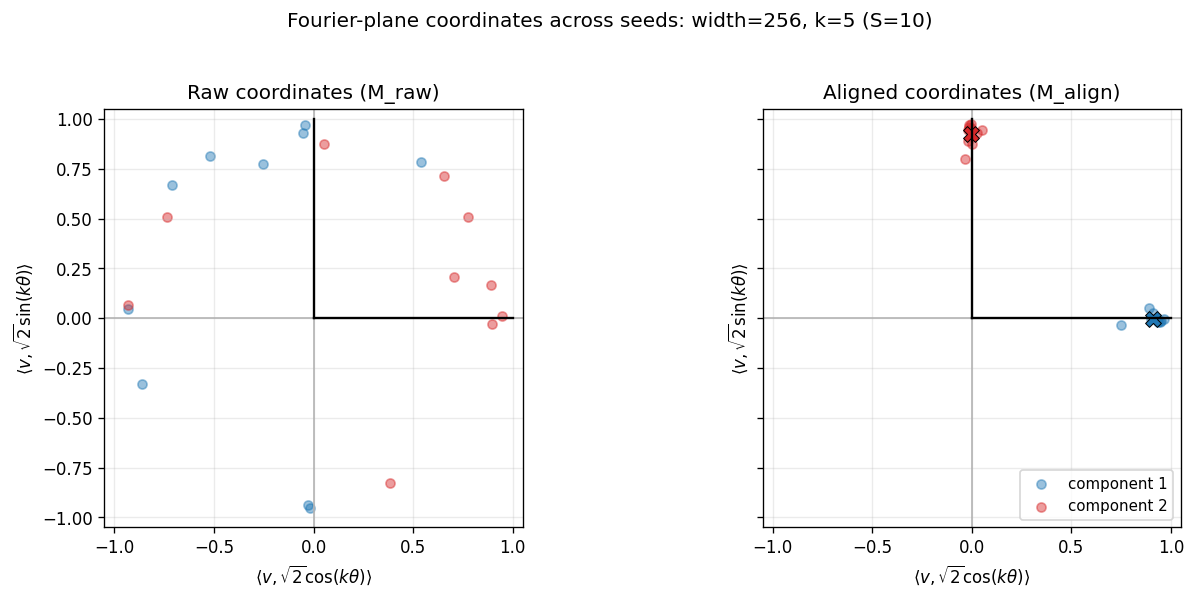

In [5]:
PLANE_WIDTH = 256 #int(widths[-1])
PLANE_K = 5

plane = aligned_components_across_seeds(PLANE_WIDTH, PLANE_K)
if plane['d'] != 2:
    raise ValueError('cos/sin plane plot requires k >= 1 (2D subspace).')

raw = plane['coeff_raw']         # [S,2,2]
aligned = plane['coeff_aligned'] # [S,2,2]
seeds_used = plane['seeds']

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8), sharex=True, sharey=True)
titles = ['Raw coordinates (M_raw)', 'Aligned coordinates (M_align)']
mats = [raw, aligned]
colors = ['C0', 'C3']  # comp1, comp2
labels_comp = ['component 1', 'component 2']

for ax, title, mats_s in zip(axes, titles, mats):
    ax.axhline(0.0, color='0.7', linewidth=1.0)
    ax.axvline(0.0, color='0.7', linewidth=1.0)
    ax.plot([0, 1], [0, 0], color='black', linewidth=1.4)
    ax.plot([0, 0], [0, 1], color='black', linewidth=1.4)

    for comp in range(2):
        xs = mats_s[:, comp, 0]
        ys = mats_s[:, comp, 1]
        ax.scatter(xs, ys, s=30, alpha=0.45, color=colors[comp], label=labels_comp[comp])
        if title != 'Raw coordinates (M_raw)':
            ax.scatter([np.mean(xs)], [np.mean(ys)], s=90, marker='X', color=colors[comp], edgecolor='black', linewidth=0.6)

    lim = 1.05
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(r'$\langle v, \sqrt{2}\cos(k\theta)\rangle$')
    ax.set_ylabel(r'$\langle v, \sqrt{2}\sin(k\theta)\rangle$')
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

axes[1].legend(loc='lower right', fontsize=9)
fig.suptitle(
    f'Fourier-plane coordinates across seeds: width={PLANE_WIDTH}, k={PLANE_K} (S={len(seeds_used)})',
    y=1.03,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_fourier_plane_raw_vs_aligned_w{PLANE_WIDTH}_k{PLANE_K}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## A3) Raw Fourier-Plane Coordinates Across Multiple Frequencies

This section shows pre-Procrustes structure across several frequencies:
$$(x,y)=\big(\langle v,\sqrt{2}\cos(k\theta)\rangle,\langle v,\sqrt{2}\sin(k\theta)\rangle\big).$$

Use it to see where clouds are already tight vs where strong in-plane mixing remains.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_fourier_plane_raw_multi_freq_w1024.png


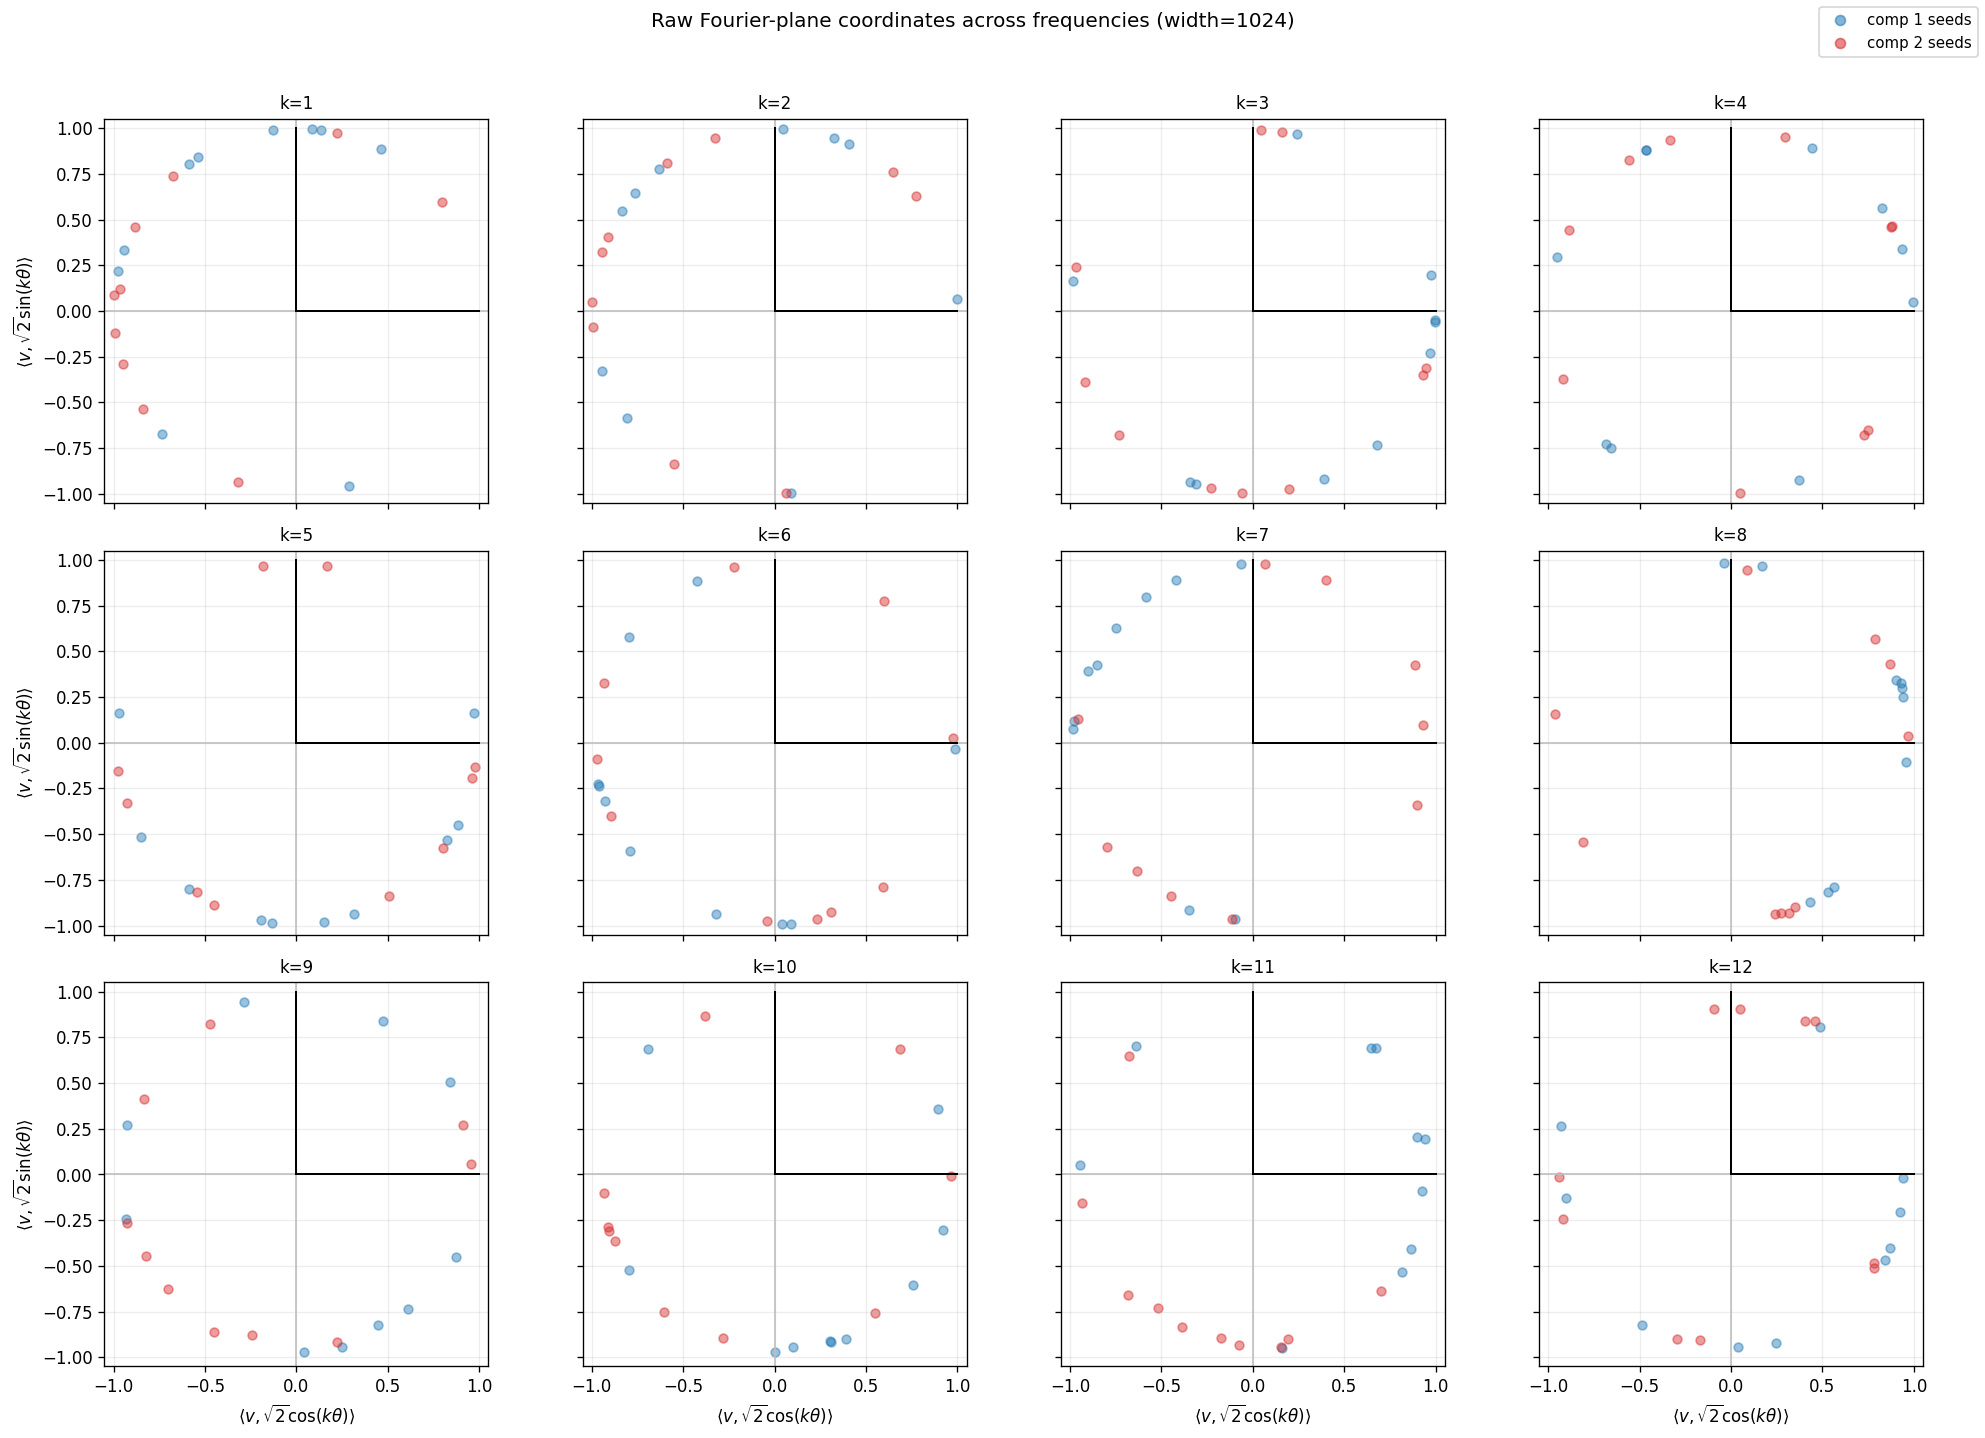

In [6]:
RAW_MULTI_WIDTH = int(widths[-1])
RAW_MULTI_FREQS = keep_existing(frequencies.tolist(), frequencies.tolist())
RAW_MULTI_FREQS = [int(k) for k in RAW_MULTI_FREQS if int(k) >= 1]
RAW_MULTI_NCOLS = 4

if len(RAW_MULTI_FREQS) == 0:
    raise RuntimeError('No frequencies >=1 available for raw multi-frequency plane plot.')

n_panels = len(RAW_MULTI_FREQS)
n_cols = min(RAW_MULTI_NCOLS, n_panels)
n_rows = int(np.ceil(n_panels / n_cols))

max_dim = max(n_rows, n_cols)
if max_dim >= 8:
    width_per_col, height_per_row = 4.8, 4.4
elif max_dim >= 6:
    width_per_col, height_per_row = 4.5, 4.1
else:
    width_per_col, height_per_row = 4.2, 3.9

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(width_per_col * n_cols, height_per_row * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.asarray(axes).reshape(-1)

for panel_idx, k in enumerate(RAW_MULTI_FREQS):
    ax = axes[panel_idx]
    st = aligned_components_across_seeds(RAW_MULTI_WIDTH, int(k))
    if st['d'] != 2:
        ax.axis('off')
        continue

    raw = st['coeff_raw']  # [S,2,2]

    ax.axhline(0.0, color='0.75', linewidth=1.0)
    ax.axvline(0.0, color='0.75', linewidth=1.0)
    ax.plot([0, 1], [0, 0], color='black', linewidth=1.2)
    ax.plot([0, 0], [0, 1], color='black', linewidth=1.2)

    for comp, color in enumerate(['C0', 'C3']):
        xs = raw[:, comp, 0]
        ys = raw[:, comp, 1]
        ax.scatter(xs, ys, s=28, alpha=0.45, color=color)

    ax.set_title(f'k={int(k)}', fontsize=10)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.22)

for j in range(n_panels, len(axes)):
    axes[j].axis('off')

for r in range(n_rows):
    for c in range(n_cols):
        idx = r * n_cols + c
        if idx >= len(axes) or idx >= n_panels:
            continue
        ax = axes[idx]
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        if r == n_rows - 1:
            ax.set_xlabel(r'$\langle v, \sqrt{2}\cos(k\theta)\rangle$')
        if c == 0:
            ax.set_ylabel(r'$\langle v, \sqrt{2}\sin(k\theta)\rangle$')

legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='None', color='C0', alpha=0.55, label='comp 1 seeds'),
    plt.Line2D([0], [0], marker='o', linestyle='None', color='C3', alpha=0.55, label='comp 2 seeds'),
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=9)
fig.suptitle(
    f'Raw Fourier-plane coordinates across frequencies (width={RAW_MULTI_WIDTH})',
    y=1.02,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_fourier_plane_raw_multi_freq_w{RAW_MULTI_WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## A4) Multi-Seed Mean ± Spread: Eigenvector Shapes

For one `(width, k)`, we aggregate aligned components across seeds and plot mean ± std over angle.
This shows which component shapes are stable and where seed variability is still large.


width=256, k=5, seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
component source: saved
Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_shape_mean_spread_w256_k5.png


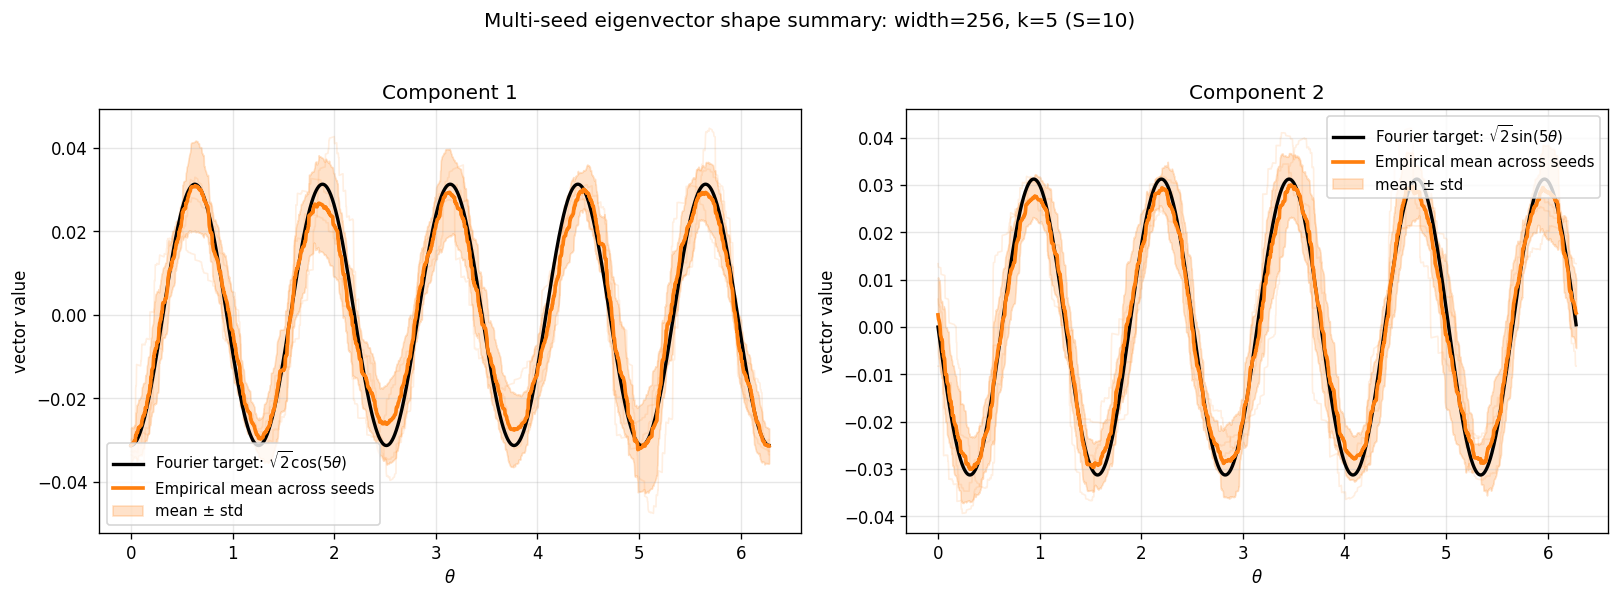

In [7]:
MEAN_WIDTH = 256 #int(widths[-1])
MEAN_K = 5
SHOW_FEW_SEEDS = 3  # light overlay for a few seeds

multi = aligned_components_across_seeds(MEAN_WIDTH, MEAN_K)
F = multi['F']
labels = multi['labels']
d = multi['d']
aligned = multi['aligned']
mean = multi['mean']
std = multi['std']
seed_ids = multi['seeds']

print(f'width={MEAN_WIDTH}, k={MEAN_K}, seeds={seed_ids.tolist()}')
print('component source:', multi['source'])

fig, axes = plt.subplots(1, d, figsize=(6.8 * d, 4.8), sharex=True)
if d == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    for s in range(min(SHOW_FEW_SEEDS, aligned.shape[0])):
        ax.plot(theta, aligned[s, j, :], color='C1', alpha=0.12, linewidth=1.0)

    ax.plot(theta, F[:, j], color='black', linewidth=2.0, label=f'Fourier target: {labels[j]}')
    ax.plot(theta, mean[j, :], color='C1', linewidth=2.2, label='Empirical mean across seeds')
    ax.fill_between(theta, mean[j, :] - std[j, :], mean[j, :] + std[j, :], color='C1', alpha=0.22, label='mean ± std')

    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel('vector value')
    ax.set_title(f'Component {j + 1}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle(
    f'Multi-seed eigenvector shape summary: width={MEAN_WIDTH}, k={MEAN_K} (S={aligned.shape[0]})',
    y=1.03,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_shape_mean_spread_w{MEAN_WIDTH}_k{MEAN_K}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## A5) Grid View (4x4 or 8x8) of Multiple Components

Each panel compares Fourier target shape (black) against empirical aligned mean ± std band (orange) for one `(frequency, component)` pair.
This gives a compact scan of many modes at once.


Grid width=1024, panels=14, rows=7, cols=2, frequencies=[2, 3, 4, 5, 6, 7, 8], data source=['saved']
Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_shape_grid_7x2_w1024.png


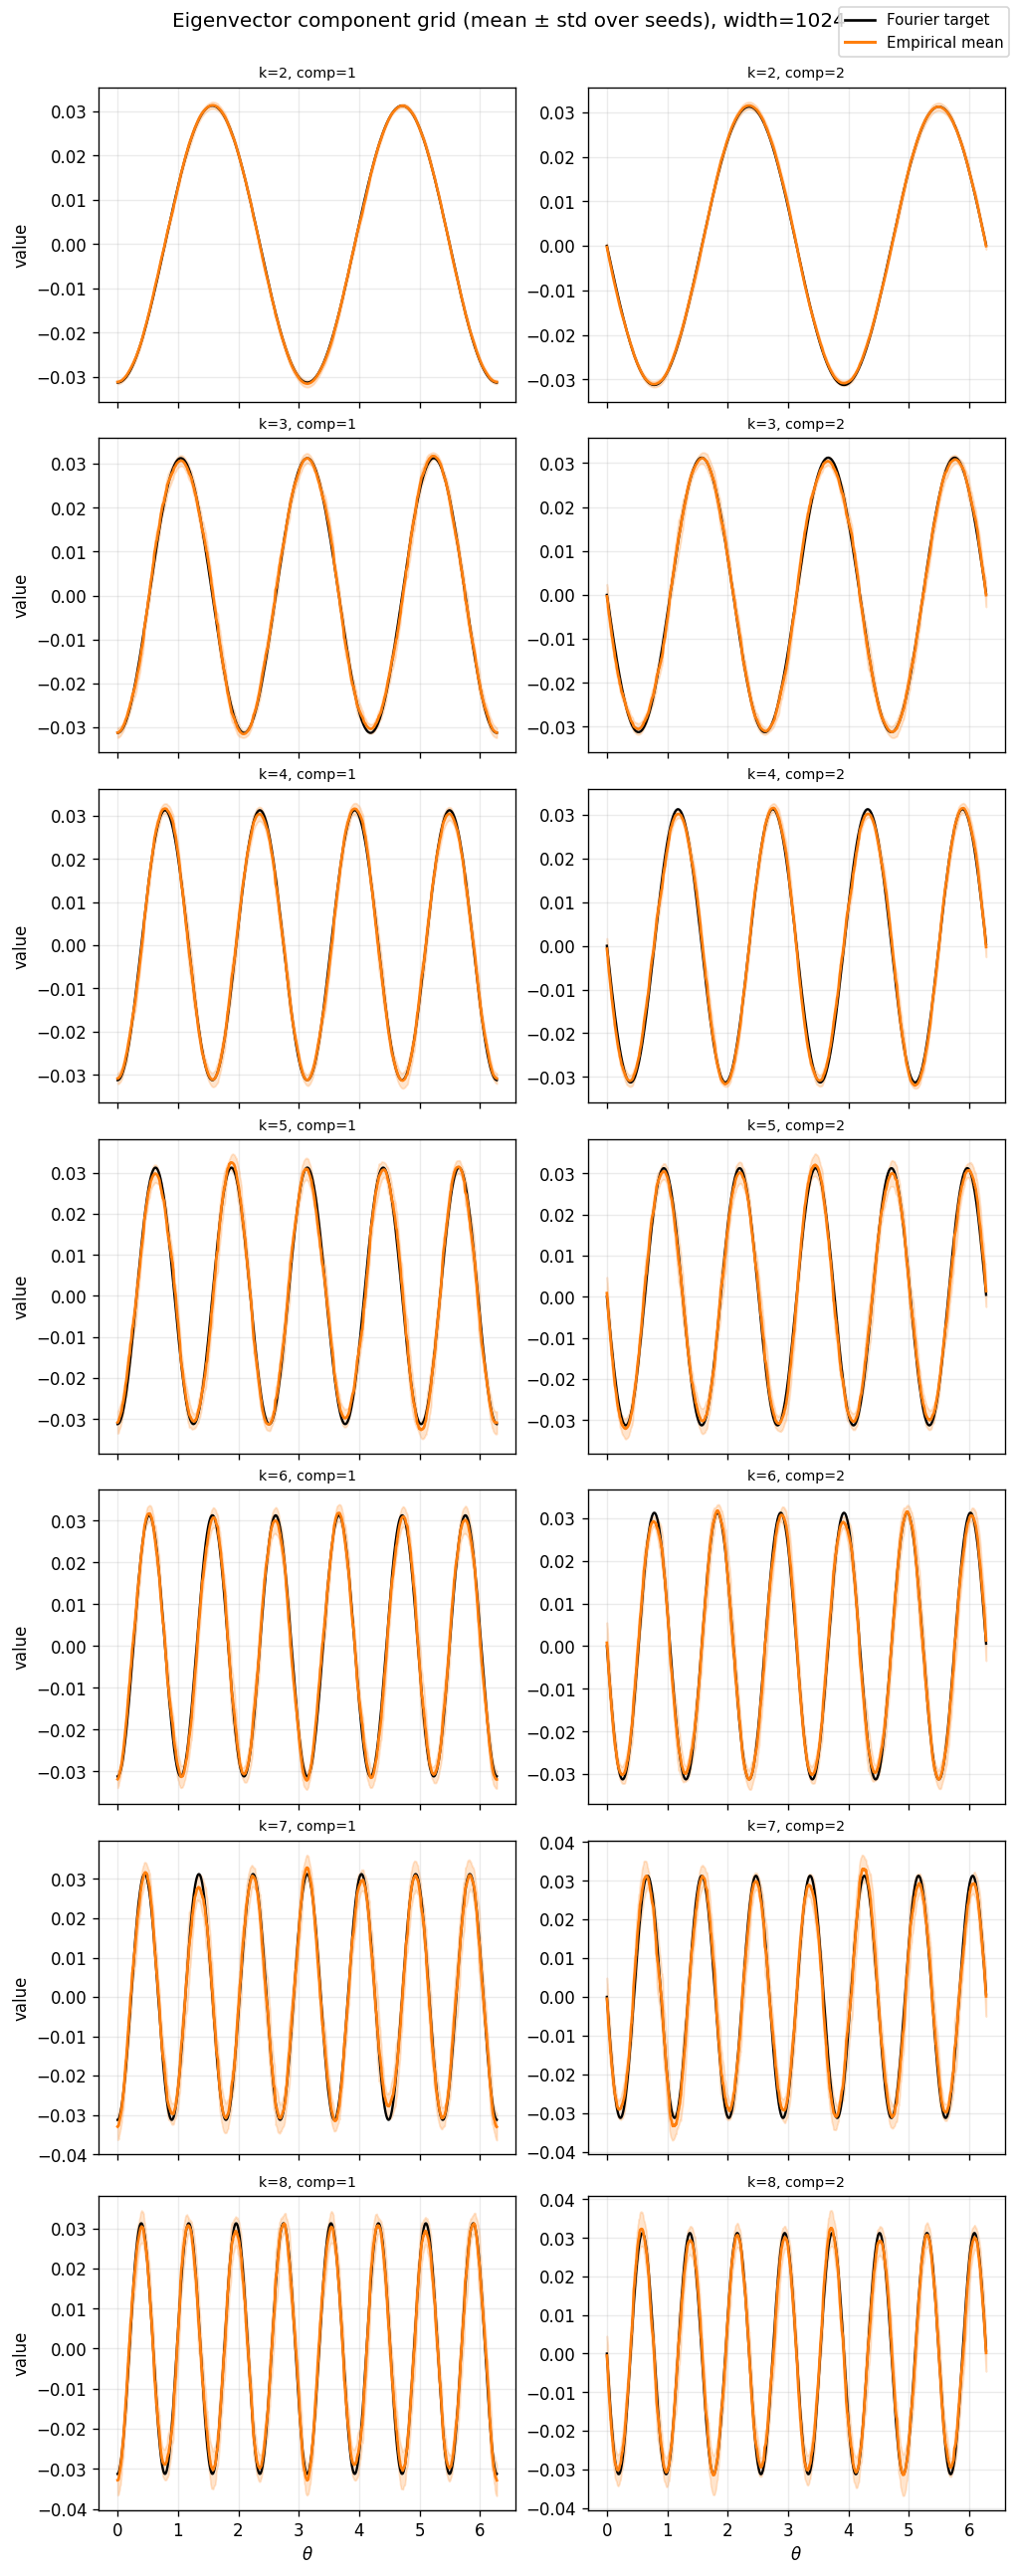

In [8]:
GRID_WIDTH = int(widths[-1])
GRID_START_K = 1
GRID_INCLUDE_K0 = False
GRID_MAX_COLS = 6  # upper bound, not fixed columns
GRID_FREQS = keep_existing([2, 3, 4, 5, 6, 7, 8], frequencies.tolist())
GRID_FREQS = [int(k) for k in GRID_FREQS if int(k) >= GRID_START_K]
if GRID_INCLUDE_K0 and 0 in keep_existing([0], frequencies.tolist()):
    GRID_FREQS = [0] + GRID_FREQS
GRID_FREQS = sorted(set(int(k) for k in GRID_FREQS))
pairs = []
for k in GRID_FREQS:
    if k == 0:
        pairs.append((0, 0))
    else:
        pairs.append((k, 0))
        pairs.append((k, 1))
if len(pairs) == 0:
    raise RuntimeError("No (k, component) pairs selected for the requested grid.")
n_panels = len(pairs)
def best_grid(n, max_cols=6):
    max_cols = min(max_cols, n)
    best = None
    for c in range(1, max_cols + 1):
        r = int(np.ceil(n / c))
        empty = r * c - n
        shape_penalty = abs(r - c)  # prefer near-square among equal-empty layouts
        score = (empty, shape_penalty)
        if best is None or score < best[0]:
            best = (score, r, c)
    _, rows, cols = best
    return rows, cols
GRID_ROWS, GRID_COLS = best_grid(n_panels, GRID_MAX_COLS)
stats_by_k = {}
for k in sorted({k for k, _ in pairs}):
    stats_by_k[k] = aligned_components_across_seeds(GRID_WIDTH, k)
sources = sorted({stats_by_k[k]["source"] for k in stats_by_k})
print(
    f"Grid width={GRID_WIDTH}, panels={n_panels}, rows={GRID_ROWS}, cols={GRID_COLS}, "
    f"frequencies={sorted({k for k, _ in pairs})}, data source={sources}"
)
max_dim = max(GRID_ROWS, GRID_COLS)
if max_dim >= 8:
    width_per_col, height_per_row = 4.8, 3.3
    title_fs = 8
elif max_dim >= 6:
    width_per_col, height_per_row = 4.2, 3.0
    title_fs = 8.5
else:
    width_per_col, height_per_row = 3.8, 2.7
    title_fs = 9
fig, axes = plt.subplots(
    GRID_ROWS,
    GRID_COLS,
    figsize=(width_per_col * GRID_COLS, height_per_row * GRID_ROWS),
    sharex=True,
    sharey=False,
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()
for idx, ax in enumerate(axes):
    if idx >= n_panels:
        fig.delaxes(ax)  # remove unused axes completely
        continue
    k, comp = pairs[idx]
    st = stats_by_k[k]
    if comp >= st["d"]:
        fig.delaxes(ax)
        continue
    y_ref = st["F"][:, comp]
    y_mean = st["mean"][comp, :]
    y_std = st["std"][comp, :]
    ax.plot(theta, y_ref, color="black", linewidth=1.4)
    ax.plot(theta, y_mean, color="C1", linewidth=1.6)
    ax.fill_between(theta, y_mean - y_std, y_mean + y_std, color="C1", alpha=0.2)
    ax.set_title(f"k={k}, comp={comp + 1}", fontsize=title_fs)
    ax.grid(True, alpha=0.25)
    # column index and row index in the dynamic grid
    col = idx % GRID_COLS
    row = idx // GRID_COLS
    if col == 0:
        ax.set_ylabel("value")
    if row == GRID_ROWS - 1:
        ax.set_xlabel(r"$\theta$")
legend_handles = [
    plt.Line2D([0], [0], color="black", linewidth=1.6, label="Fourier target"),
    plt.Line2D([0], [0], color="C1", linewidth=1.8, label="Empirical mean"),
]
fig.legend(handles=legend_handles, loc="upper right", fontsize=9)
fig.suptitle(
    f"Eigenvector component grid (mean ± std over seeds), width={GRID_WIDTH}",
    y=1.02,
)
filename = PLOT_DIR / f"eigenvector_shape_grid_{GRID_ROWS}x{GRID_COLS}_w{GRID_WIDTH}.png"
plt.savefig(filename, bbox_inches="tight")
print(f"Successfully saved {filename}")
plt.show()

## A6) Plot 1: Projector Error vs Width

Lower is better: these curves show how quickly Fourier-subspace alignment improves as width grows.
Projector distances are basis-invariant and are the core alignment metric.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/projector_error_vs_width.png


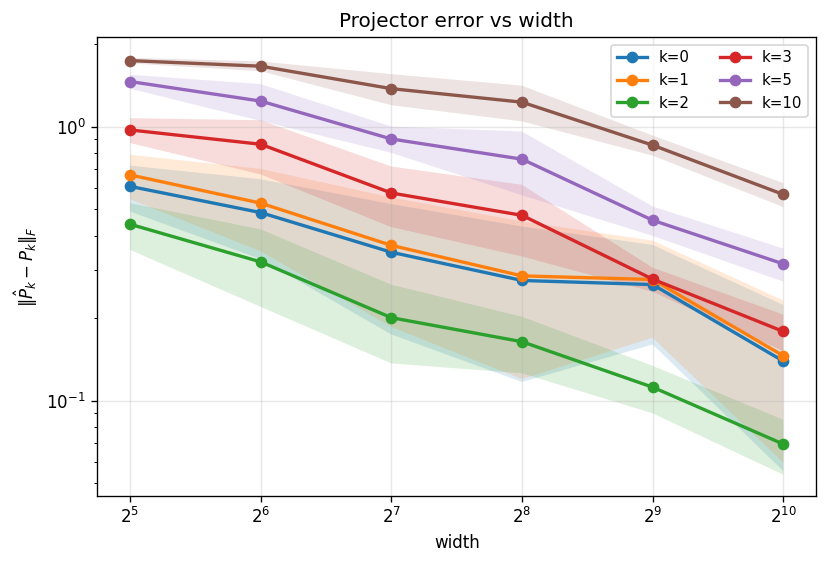

In [4]:
freqs_to_plot = keep_existing([0, 1, 2, 3, 5, 10, 15, 20], frequencies.tolist())

plt.figure(figsize=(7.0, 4.8))
for k in freqs_to_plot:
    j = fidx(k)
    y = projector_fro_mean[:, j]
    e = projector_fro_std[:, j]
    plt.plot(widths, y, marker='o', linewidth=2, label=f'k={k}')
    plt.fill_between(widths, y - e, y + e, alpha=0.16)

# plt.axhline(projector_fro_tol, linestyle='--', color='black', linewidth=1.2, label='tolerance')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('width')
plt.ylabel(r'$\|\hat{P}_k - P_k\|_F$')
plt.title('Projector error vs width')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

filename = PLOT_DIR / 'projector_error_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## A7) Plot 2: Projector Error vs Frequency

At fixed widths this reveals frequency difficulty directly.
Typically, higher frequencies retain larger subspace mismatch for the same width.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/projector_error_vs_frequency.png


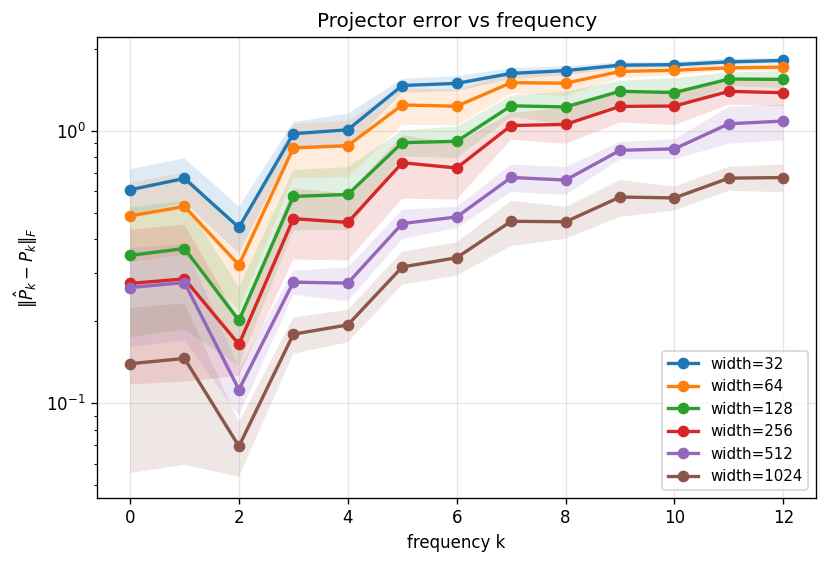

In [10]:
widths_to_plot = keep_existing([32, 64, 128, 256, 512, 1024], widths.tolist())

plt.figure(figsize=(7.0, 4.8))
for w in widths_to_plot:
    i = widx(w)
    y = projector_fro_mean[i, :]
    e = projector_fro_std[i, :]
    plt.plot(frequencies, y, marker='o', linewidth=2, label=f'width={w}')
    plt.fill_between(frequencies, y - e, y + e, alpha=0.14)

# plt.axhline(projector_fro_tol, linestyle='--', color='black', linewidth=1.2, label='tolerance')
plt.yscale('log')
plt.xlabel('frequency k')
plt.ylabel(r'$\|\hat{P}_k - P_k\|_F$')
plt.title('Projector error vs frequency')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()

filename = PLOT_DIR / 'projector_error_vs_frequency.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## A7b) Cumulative Projector Error vs Width

Cumulative subspace diagnostics for $F_{\le k}$ allow us to ask whether alignment issues
persist beyond single-frequency planes.

This plot mirrors A6, but uses cumulative projector error $\|\hat P_{\le k}-P_{\le k}\|_F$.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/cumulative_projector_error_vs_width.png


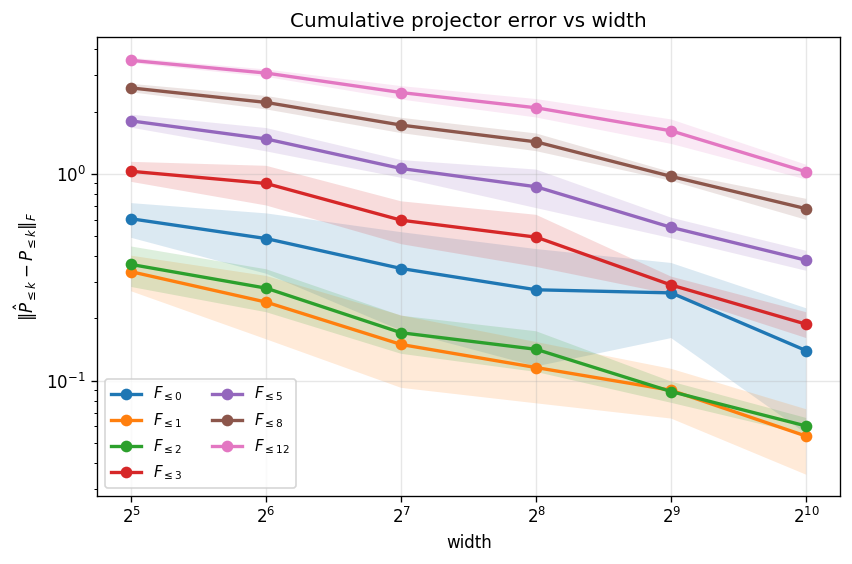

In [13]:
cutoffs_to_plot = keep_existing([0, 1, 2, 3, 5, 8, 12], cumulative_cutoffs.tolist())

plt.figure(figsize=(7.2, 4.8))
for k in cutoffs_to_plot:
    j = cidx(k)
    y = cumulative_projector_fro_mean[:, j]
    e = cumulative_projector_fro_std[:, j]
    plt.plot(widths, y, marker='o', linewidth=2, label=rf'$F_{{\leq {k}}}$')
    plt.fill_between(widths, y - e, y + e, alpha=0.16)

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('width')
plt.ylabel(r'$\|\hat{P}_{\leq k} - P_{\leq k}\|_F$')
plt.title('Cumulative projector error vs width')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

filename = PLOT_DIR / 'cumulative_projector_error_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## A7c) Cumulative Metrics vs Cutoff

This plot mirrors A7, but on cumulative subspaces:
- left: cumulative projector error vs cutoff,
- right: cumulative RMS-cos affinity vs cutoff.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/cumulative_metrics_vs_cutoff.png


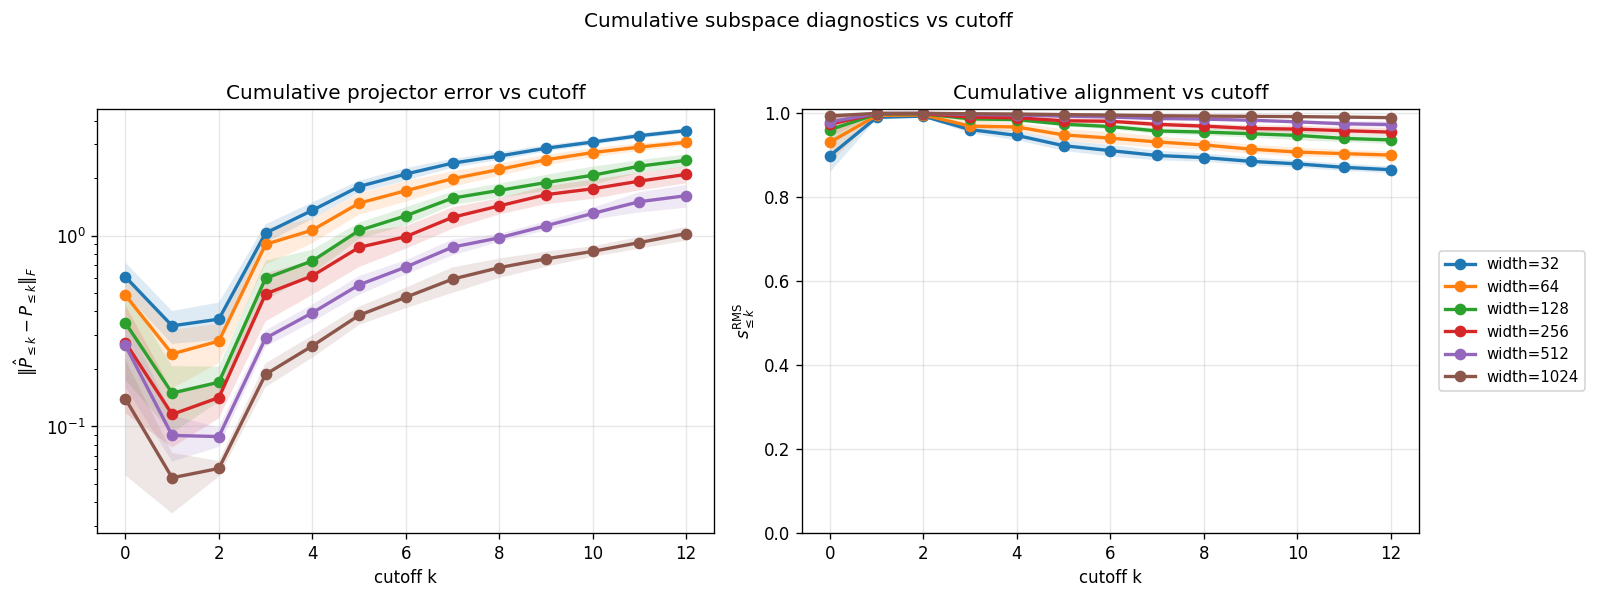

In [15]:
widths_to_plot = keep_existing([32, 64, 128, 256, 512, 1024], widths.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8), sharex=True)
ax_err, ax_aff = axes

for w in widths_to_plot:
    i = widx(w)

    y_err = cumulative_projector_fro_mean[i, :]
    e_err = cumulative_projector_fro_std[i, :]
    ax_err.plot(cumulative_cutoffs, y_err, marker='o', linewidth=2, label=f'width={w}')
    ax_err.fill_between(cumulative_cutoffs, y_err - e_err, y_err + e_err, alpha=0.14)

    y_aff = cumulative_affinity_rms_mean[i, :]
    e_aff = cumulative_affinity_rms_std[i, :]
    ax_aff.plot(cumulative_cutoffs, y_aff, marker='o', linewidth=2, label=f'width={w}')
    ax_aff.fill_between(
        cumulative_cutoffs,
        np.maximum(y_aff - e_aff, 0.0),
        np.minimum(y_aff + e_aff, 1.0),
        alpha=0.14,
    )

ax_err.set_yscale('log')
ax_err.set_xlabel('cutoff k')
ax_aff.set_xlabel('cutoff k')
ax_err.set_ylabel(r'$\|\hat{P}_{\leq k} - P_{\leq k}\|_F$')
ax_aff.set_ylabel(r'$s_{\leq k}^{\mathrm{RMS}}$')
ax_err.set_title('Cumulative projector error vs cutoff')
ax_aff.set_title('Cumulative alignment vs cutoff')
ax_err.grid(True, alpha=0.3)
ax_aff.grid(True, alpha=0.3)
ax_aff.set_ylim(0.0, 1.01)
ax_aff.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.suptitle('Cumulative subspace diagnostics vs cutoff', y=1.03)
fig.tight_layout()

filename = PLOT_DIR / 'cumulative_metrics_vs_cutoff.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## A8) Plot 3: Principal Angles vs Width

Principal angles provide a direct geometric measure of Fourier-plane alignment at initialization.
For each frequency $k\ge 1$, the matched empirical and Fourier subspaces are both 2D, giving two angles
$\theta_{k,1} \le \theta_{k,2} \in [0^\circ,90^\circ]$.

Interpretation:
- small angles: strong subspace alignment (frozen NTK is Fourier-like on that plane),
- large angles: substantial mixing with other frequencies.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/principal_angles_vs_width.png


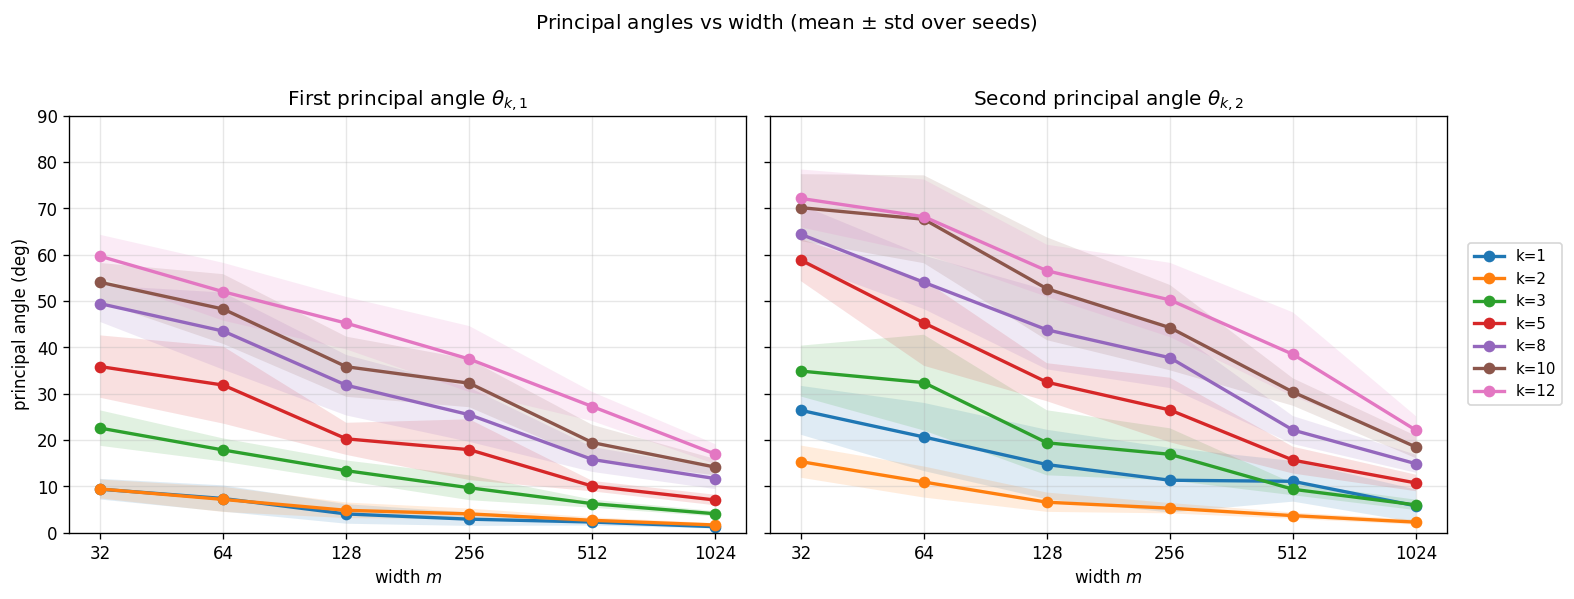

In [16]:
freqs_for_angles = keep_existing([1, 2, 3, 5, 8, 10, 12], frequencies.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), sharex=True, sharey=True)

for k in freqs_for_angles:
    j = fidx(k)

    a1 = np.rad2deg(principal_angles_mean[:, j, 0])
    s1 = np.rad2deg(principal_angles_std[:, j, 0])
    lo1 = np.clip(a1 - s1, 0.0, 90.0)
    hi1 = np.clip(a1 + s1, 0.0, 90.0)
    axes[0].plot(widths, a1, marker='o', linewidth=2, label=f'k={k}')
    axes[0].fill_between(widths, lo1, hi1, alpha=0.14)

    a2 = np.rad2deg(principal_angles_mean[:, j, 1])
    s2 = np.rad2deg(principal_angles_std[:, j, 1])
    lo2 = np.clip(a2 - s2, 0.0, 90.0)
    hi2 = np.clip(a2 + s2, 0.0, 90.0)
    axes[1].plot(widths, a2, marker='o', linewidth=2, label=f'k={k}')
    axes[1].fill_between(widths, lo2, hi2, alpha=0.14)

for ax in axes:
    ax.set_xscale('log', base=2)
    ax.set_ylim(0.0, 90.0)
    ax.set_yticks(np.arange(0, 91, 10))
    ax.set_xticks(widths)
    ax.set_xticklabels([str(w) for w in widths])
    ax.set_xlabel('width $m$')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('principal angle (deg)')
axes[0].set_title(r'First principal angle $\theta_{k,1}$')
axes[1].set_title(r'Second principal angle $\theta_{k,2}$')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.suptitle('Principal angles vs width (mean $\pm$ std over seeds)', y=1.03)
fig.tight_layout()

filename = PLOT_DIR / 'principal_angles_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## A8b) RMS-Cos Similarity vs Width

This mirrors the evolving-kernel RMS-cos view, now for frozen eigenspace alignment at initialization.
For each frequency $k\ge 1$, using principal angles $\theta_{k,1},\theta_{k,2}$ between $F_k$ and $\hat F_k$:
$$s_k^{\mathrm{RMS}}=\sqrt{\frac{\cos^2\theta_{k,1}+\cos^2\theta_{k,2}}{2}}. $$
Higher is better (closer to 1 means stronger subspace alignment).


/var/folders/yy/f08jrfk55s3_yrjg0s_jfggc0000gn/T/ipykernel_66132/4290132734.py:17: RuntimeWarning: Mean of empty slice
  rms_cos_mean[i, :] = np.nanmean(rms_w, axis=0)
/Users/shreyas/Documents/msc-cs/msc-thesis/code/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Successfully saved plots/ntk_eigenspace_alignment_on_S1/rms_cos_similarity_vs_width.png


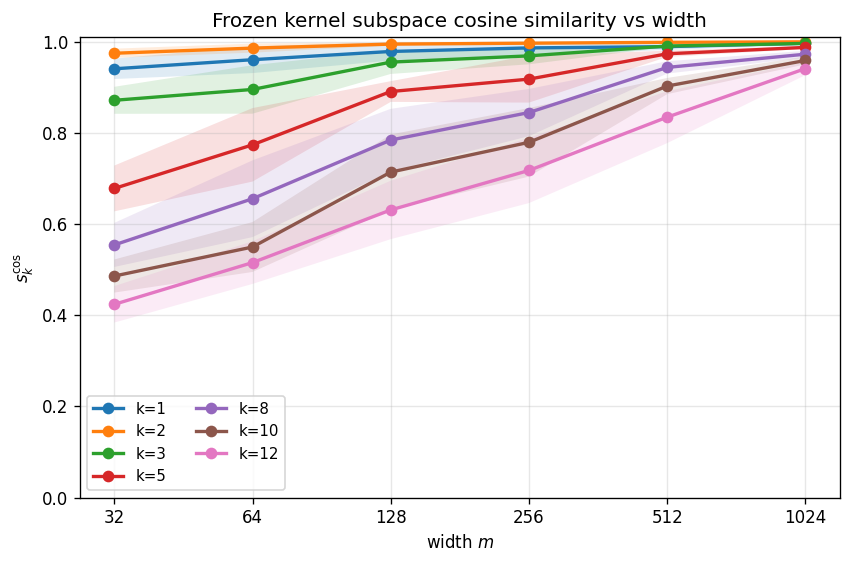

In [7]:
freqs_for_rms = keep_existing([1, 2, 3, 5, 8, 10, 12], frequencies.tolist())

rms_cos_mean = np.full((len(widths), len(frequencies)), np.nan, dtype=float)
rms_cos_std = np.full((len(widths), len(frequencies)), np.nan, dtype=float)

for i, w in enumerate(widths):
    run_w = npz(run_dir, manifest['runs'][str(int(w))])
    if 'principal_angles' not in run_w:
        raise RuntimeError(
            f'Run for width={int(w)} is missing principal_angles. '
            'Please rerun experiments/ntk_eigenspace_alignment_on_S1.py with the latest script.'
        )

    angles_w = np.asarray(run_w['principal_angles'], dtype=float)  # [seed, K, 2]
    rms_w = np.sqrt(np.mean(np.cos(angles_w) ** 2, axis=2))        # [seed, K]

    rms_cos_mean[i, :] = np.nanmean(rms_w, axis=0)
    rms_cos_std[i, :] = np.nanstd(rms_w, axis=0)

plt.figure(figsize=(7.2, 4.8))
for k in freqs_for_rms:
    j = fidx(k)
    y = rms_cos_mean[:, j]
    e = rms_cos_std[:, j]
    plt.plot(widths, y, marker='o', linewidth=2, label=f'k={k}')
    plt.fill_between(widths, np.maximum(y - e, 0.0), np.minimum(y + e, 1.0), alpha=0.14)

plt.xscale('log', base=2)
plt.ylim(0.0, 1.01)
plt.xticks(widths, [str(w) for w in widths])
plt.xlabel('width $m$')
plt.ylabel(r'$s_k^{\mathrm{cos}}$')
plt.title('Frozen kernel subspace cosine similarity vs width')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

filename = PLOT_DIR / 'rms_cos_similarity_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## A9) Plot 4: Eigenvalue Error vs Frequency

Left: absolute center error between matched empirical eigenvalue and continuum reference.
Right: pair splitting inside each matched 2D empirical eigenspace.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvalue_error_vs_frequency.png


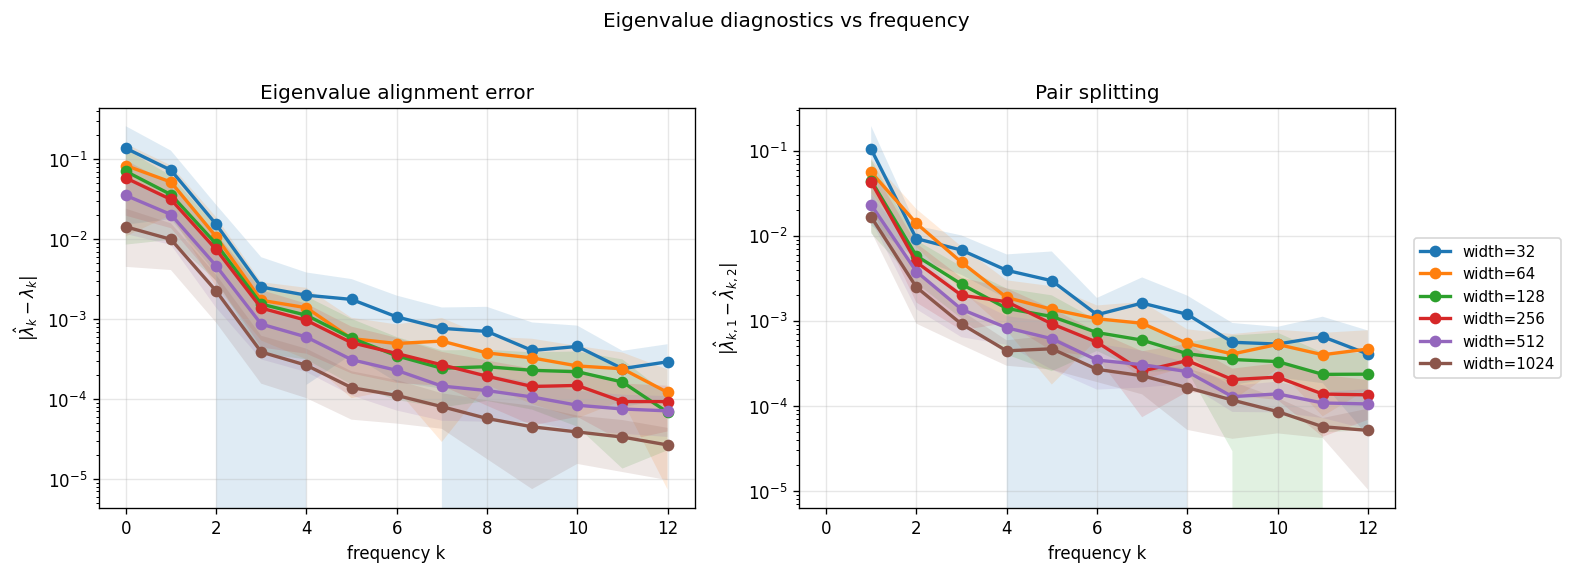

In [17]:
widths_to_plot = keep_existing([32, 64, 128, 256, 512, 1024], widths.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), sharex=True)

for w in widths_to_plot:
    i = widx(w)

    y1 = eig_abs_error_mean[i, :]
    e1 = eig_abs_error_std[i, :]
    axes[0].plot(frequencies, y1, marker='o', linewidth=2, label=f'width={w}')
    axes[0].fill_between(frequencies, y1 - e1, y1 + e1, alpha=0.14)

    y2 = pair_splitting_mean[i, :]
    e2 = pair_splitting_std[i, :]
    axes[1].plot(frequencies, y2, marker='o', linewidth=2, label=f'width={w}')
    axes[1].fill_between(frequencies, y2 - e2, y2 + e2, alpha=0.14)

axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].set_xlabel('frequency k')
axes[1].set_xlabel('frequency k')
axes[0].set_ylabel(r'$|\hat{\lambda}_k - \lambda_k|$')
axes[1].set_ylabel(r'$|\hat{\lambda}_{k,1} - \hat{\lambda}_{k,2}|$')
axes[0].set_title('Eigenvalue alignment error')
axes[1].set_title('Pair splitting')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.suptitle('Eigenvalue diagnostics vs frequency', y=1.03)
fig.tight_layout()

filename = PLOT_DIR / 'eigenvalue_error_vs_frequency.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## A10) Baseline Diagnostics

We summarize threshold-based alignment diagnostics, including:

- minimum width where projector error drops below tolerance per frequency,
- frequencies still failing tolerance at the maximum width.


In [18]:
print(f'Projector Frobenius tolerance: {projector_fro_tol:.4g}')
print('')
print('Minimum width for small projector error by frequency:')
for k, w in zip(frequencies, min_width_for_small_error):
    tag = 'not reached' if int(w) < 0 else str(int(w))
    print(f'  k={int(k):2d}: {tag}')

print('')
if len(failing_freqs_at_max_width) == 0:
    print('All frequencies satisfy tolerance at largest width.')
else:
    print(
        'Frequencies failing tolerance at largest width',
        int(widths[-1]),
        ':',
        failing_freqs_at_max_width.tolist(),
    )

Projector Frobenius tolerance: 0.25

Minimum width for small projector error by frequency:
  k= 0: 1024
  k= 1: 1024
  k= 2: 128
  k= 3: 1024
  k= 4: 1024
  k= 5: not reached
  k= 6: not reached
  k= 7: not reached
  k= 8: not reached
  k= 9: not reached
  k=10: not reached
  k=11: not reached
  k=12: not reached

Frequencies failing tolerance at largest width 1024 : [5, 6, 7, 8, 9, 10, 11, 12]


## Part B: Reliability Extension

Part B translates geometric alignment into learning-relevant reliability on the truncated Fourier block.
We use the perturbation notation

$$E_m^{(K)} := B_m^{(K)} - \Lambda_K,$$

and track both absolute concentration (how fast $\|E_m^{(K)}\|$ shrinks with width) and relative criteria
(how large this perturbation is compared to spectral scales like $g_k$ and $\lambda_{\min,S}$).


In [19]:
# Extended reliability diagnostics (available in newer experiment outputs)
def _require_summary_key(key: str):
    if key not in summary:
        raise KeyError(
            f"Required key '{key}' not found in summary.npz. "
            "Please rerun experiments/ntk_eigenspace_alignment_on_S1.py with the latest config."
        )

for _k in [
    'local_gap',
    'relative_center_error_mean',
    'pair_splitting_over_lambda_mean',
    'pair_splitting_over_gap_mean',
    'relative_leakage_mean',
    'block_max_mean',
    'block_fro_mean',
    'block_op_mean',
    'target_support_names',
    'target_support_lambda_min',
    'target_prediction_error_mean',
    'reliability_ratio_mean',
    'support_max_projector_fro_mean',
    'support_max_relative_center_error_mean',
    'support_max_relative_leakage_mean',
    'reliability_tau',
]:
    _require_summary_key(_k)

local_gap = np.asarray(summary['local_gap'], dtype=float)
relative_center_error_mean = np.asarray(summary['relative_center_error_mean'], dtype=float)
pair_splitting_over_lambda_mean = np.asarray(summary['pair_splitting_over_lambda_mean'], dtype=float)
pair_splitting_over_gap_mean = np.asarray(summary['pair_splitting_over_gap_mean'], dtype=float)
relative_leakage_mean = np.asarray(summary['relative_leakage_mean'], dtype=float)

block_max_mean = np.asarray(summary['block_max_mean'], dtype=float)
block_fro_mean = np.asarray(summary['block_fro_mean'], dtype=float)
block_op_mean = np.asarray(summary['block_op_mean'], dtype=float)

support_names = np.asarray(summary['target_support_names']).astype(str)
support_lambda_min = np.asarray(summary['target_support_lambda_min'], dtype=float)
target_prediction_error_mean = np.asarray(summary['target_prediction_error_mean'], dtype=float)
reliability_ratio_mean = np.asarray(summary['reliability_ratio_mean'], dtype=float)
support_max_projector_fro_mean = np.asarray(summary['support_max_projector_fro_mean'], dtype=float)
support_max_relative_center_error_mean = np.asarray(summary['support_max_relative_center_error_mean'], dtype=float)
support_max_relative_leakage_mean = np.asarray(summary['support_max_relative_leakage_mean'], dtype=float)

target_specs = []
target_Ks_raw = summary['target_Ks'] if 'target_Ks' in summary else None
target_amps_raw = summary['target_amps'] if 'target_amps' in summary else None
target_phases_raw = summary['target_phases'] if 'target_phases' in summary else None
if target_Ks_raw is not None and target_amps_raw is not None and target_phases_raw is not None:
    target_Ks_raw = np.asarray(target_Ks_raw, dtype=int)
    target_amps_raw = np.asarray(target_amps_raw, dtype=float)
    target_phases_raw = np.asarray(target_phases_raw, dtype=float)
    for i, name in enumerate(support_names):
        valid = target_Ks_raw[i] >= 0
        target_specs.append({
            'name': str(name),
            'Ks': target_Ks_raw[i, valid].astype(int).tolist(),
            'amps': target_amps_raw[i, valid].astype(float).tolist(),
            'phases': target_phases_raw[i, valid].astype(float).tolist(),
        })
else:
    for item in manifest.get('meta', {}).get('target_supports', []):
        _ks = item.get('Ks', item.get('frequencies', []))
        target_specs.append({
            'name': str(item.get('name', 'unnamed')),
            'Ks': [int(k) for k in _ks],
            'amps': [float(a) for a in item.get('amps', [1.0] * len(_ks))],
            'phases': [float(p) for p in item.get('phases', [0.0] * len(_ks))],
        })

tau = float(np.ravel(summary['reliability_tau'])[0])
print('Extended reliability arrays loaded.')
print('Supports:', support_names.tolist())
print('Targets loaded:', [t['name'] for t in target_specs])
print('Reliability threshold tau:', tau)


Extended reliability arrays loaded.
Supports: ['low', 'mid', 'high', 'very_high']
Targets loaded: ['low', 'mid', 'high', 'very_high']
Reliability threshold tau: 1.0


## B0) Target formulas and waveforms

Before reliability curves, we show each target exactly and plot its waveform on $[0,2\pi)$.
Convention:

$$f_S(\theta)=\sum_j a_j\cos(K_j\theta-\phi_j).$$

With this sign convention, $\phi_j=\pi/2$ gives a $+\sin(K_j\theta)$ contribution.
This section makes target composition explicit before interpreting support-wise metrics.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

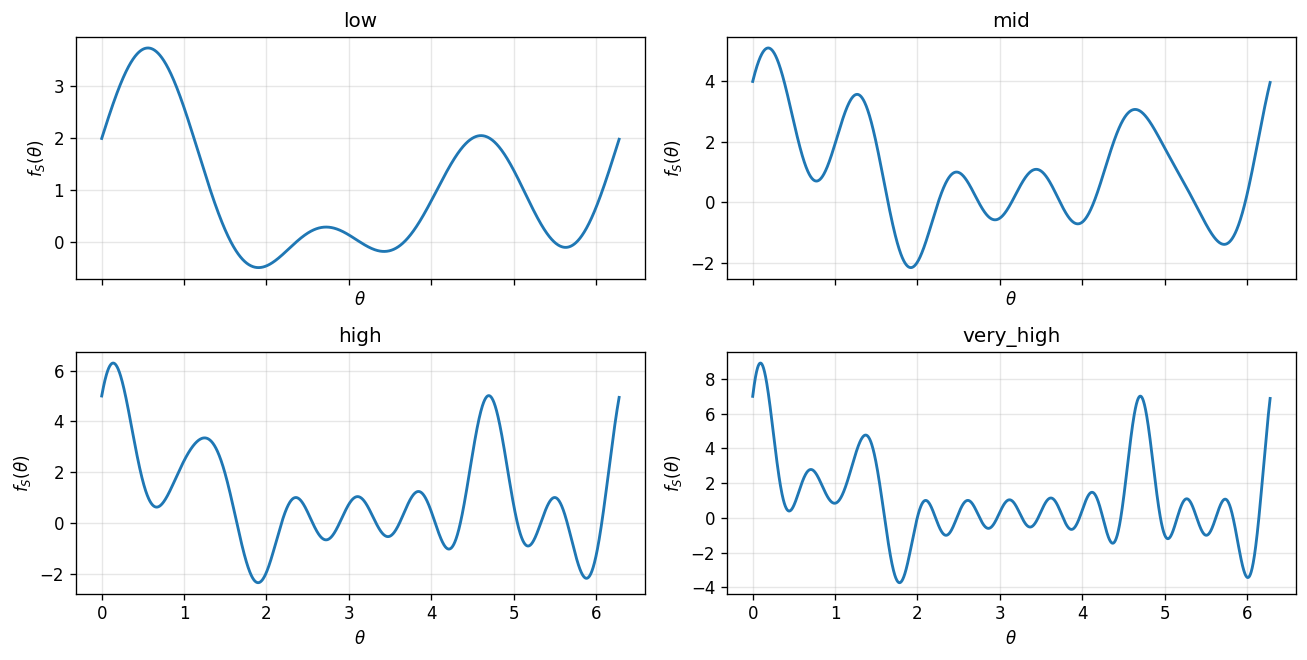

In [20]:
from IPython.display import Math, display

def _phase_tex(phi: float) -> str:
    if np.isclose(phi, 0.0, atol=1e-10):
        return '0'
    if np.isclose(phi, np.pi / 2.0, atol=1e-8):
        return r'\frac{\pi}{2}'
    if np.isclose(phi, np.pi, atol=1e-8):
        return r'\pi'
    return f'{phi:.4f}'

def _term_tex(k: int, a: float, phi: float) -> str:
    if k == 0:
        return f'{a:.4g}\\cos({_phase_tex(phi)})'
    return f'{a:.4g}\\cos({k}\\theta - {_phase_tex(phi)})'

theta_plot = np.linspace(0.0, 2.0 * np.pi, 2048, endpoint=False)

n_targets = len(target_specs)
n_col = 2
n_row = int(np.ceil(n_targets / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(11.0, 2.8 * n_row), sharex=True)
axes = np.atleast_1d(axes).ravel()

for i, spec in enumerate(target_specs):
    Ks = np.asarray(spec['Ks'], dtype=int)
    amps = np.asarray(spec['amps'], dtype=float)
    phases = np.asarray(spec['phases'], dtype=float)

    terms = [_term_tex(int(k), float(a), float(p)) for k, a, p in zip(Ks, amps, phases)]
    formula_tex = rf"f_{{{spec['name']}}}(\theta) = " + ' + '.join(terms)
    display(Math(formula_tex))

    y = np.zeros_like(theta_plot)
    for k, a, p in zip(Ks, amps, phases):
        y += a * np.cos(k * theta_plot - p)

    ax = axes[i]
    ax.plot(theta_plot, y, lw=1.7)
    ax.set_title(spec['name'])
    ax.set_ylabel(r'$f_S(\theta)$')
    ax.grid(True, alpha=0.3)

for i in range(n_targets, len(axes)):
    axes[i].axis('off')

for ax in axes:
    if ax.has_data():
        ax.set_xlabel(r'$\theta$')

fig.tight_layout()
fig.savefig(PLOT_DIR / '00_target_waveforms.png', bbox_inches='tight')
plt.show()


## B1) Spectral scale and relative eigenspace error

Before plotting errors, we need the reference spectral scales that set what "small" means.

- $\lambda_k$: continuum eigenvalue scale of frequency block $k$.
- $g_k$: local spectral separation scale,

$$g_k := \min\big(|\lambda_k-\lambda_{k-1}|,\;|\lambda_k-\lambda_{k+1}|\big),$$

with one-sided boundary handling at $k=0$ and $k=K$.

Why $g_k$ matters: subspace sensitivity is controlled by perturbation relative to separation.
With $E_m^{(K)}=B_m^{(K)}-\Lambda_K$, Davis--Kahan type behavior suggests

$$\|\widehat P_k-P_k\| \lesssim \frac{\|E_m^{(K)}\|_{op}}{g_k}. $$

So even if absolute perturbation is modest, small $g_k$ makes frequency-$k$ alignment fragile.

Why not use the cos/sin pair gap? For $k\ge 1$, the continuum pair is exactly degenerate (same $\lambda_k$),
so internal pair gap is 0. We therefore compare the 2D pair subspace to neighboring-frequency separation via $g_k$.


In [21]:
# Quick numeric view of continuum scales (for intuition)
selected_ks = keep_existing([0, 1, 2, 3, 4, 6, 8, 10, 12], frequencies.tolist())
print('k    lambda_k         g_k              lambda_k / g_k')
for k in selected_ks:
    i = fidx(k)
    lam = float(lambda_theory[i])
    gap = float(local_gap[i])
    ratio = lam / max(gap, 1e-15)
    print(f'{k:>2d}   {lam:>11.4e}   {gap:>11.4e}   {ratio:>11.4e}')


k    lambda_k         g_k              lambda_k / g_k
 0    5.5396e-01    2.0264e-01    2.7337e+00
 1    3.5132e-01    2.0264e-01    1.7337e+00
 2    7.8805e-02    6.7547e-02    1.1667e+00
 3    1.1258e-02    2.7019e-03    4.1667e+00
 4    8.5560e-03    2.7019e-03    3.1667e+00
 6    3.2257e-03    8.2711e-04    3.9000e+00
 8    1.7104e-03    3.5739e-04    4.7857e+00
10    1.0648e-03    1.8608e-04    5.7222e+00
12    7.2836e-04    1.0901e-04    6.6818e+00


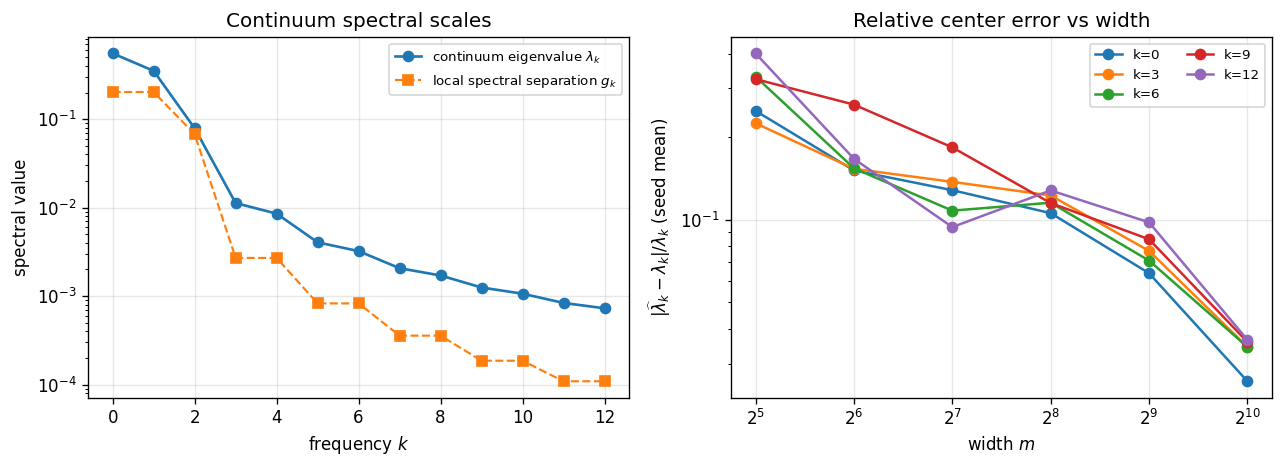

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0))
axes[0].semilogy(frequencies, lambda_theory, 'o-', lw=1.6, label=r'continuum eigenvalue $\lambda_k$')
axes[0].semilogy(
    frequencies,
    np.maximum(local_gap, 1e-16),
    's--',
    lw=1.3,
    label=r'local spectral separation $g_k$',
)
axes[0].set_title('Continuum spectral scales')
axes[0].set_xlabel('frequency $k$')
axes[0].set_ylabel('spectral value')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

for k in [0, 3, 6, 9, 12]:
    if k in frequencies:
        idx = int(np.where(frequencies == k)[0][0])
        axes[1].plot(widths, relative_center_error_mean[:, idx], 'o-', label=f'k={k}')
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log')
axes[1].set_title('Relative center error vs width')
axes[1].set_xlabel('width $m$')
axes[1].set_ylabel(r'$|\widehat{\lambda}_k-\lambda_k|/\lambda_k$ (seed mean)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=2, fontsize=8)

fig.tight_layout()
fig.savefig(PLOT_DIR / '01_spectral_scale_and_relative_error.png', bbox_inches='tight')
plt.show()


## B2) Pair splitting normalization

For each $k\ge 1$, let $\mathrm{split}_k = |\widehat\lambda_{k,1}-\widehat\lambda_{k,2}|$.
We normalize by two scales:

- $\mathrm{split}_k/\lambda_k$ (relative to signal scale),
- $\mathrm{split}_k/g_k$ (relative to neighboring-block separation).

The second quantity is the one directly tied to subspace-stability intuition.


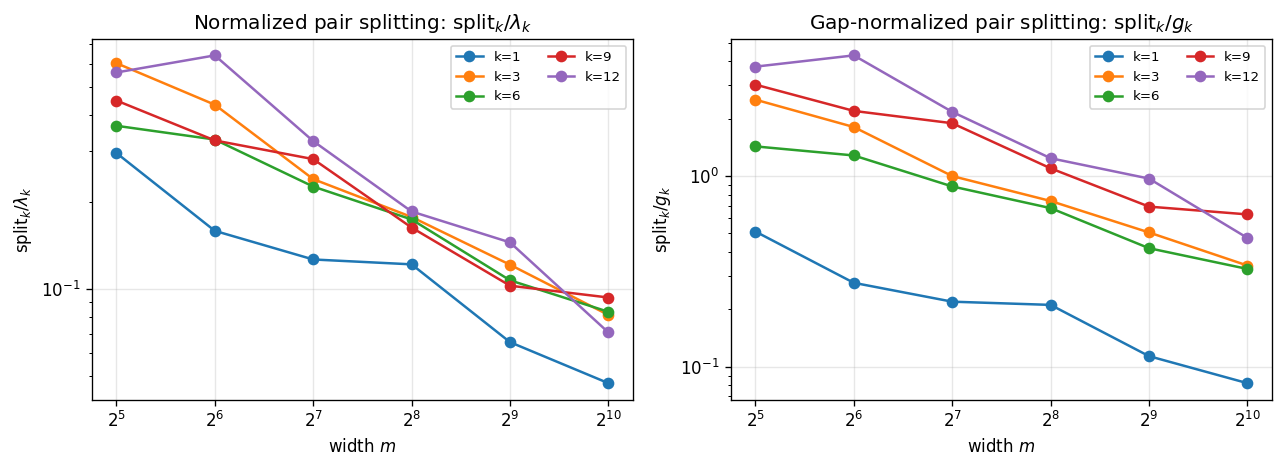

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0))
for k in [1, 3, 6, 9, 12]:
    if k in frequencies:
        idx = int(np.where(frequencies == k)[0][0])
        axes[0].plot(widths, pair_splitting_over_lambda_mean[:, idx], 'o-', label=f'k={k}')
        axes[1].plot(widths, pair_splitting_over_gap_mean[:, idx], 'o-', label=f'k={k}')

axes[0].set_title(r'Normalized pair splitting: $\mathrm{split}_k/\lambda_k$')
axes[1].set_title(r'Gap-normalized pair splitting: $\mathrm{split}_k/g_k$')
axes[0].set_ylabel(r'$\mathrm{split}_k/\lambda_k$')
axes[1].set_ylabel(r'$\mathrm{split}_k/g_k$')

for ax in axes:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('width $m$')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

fig.tight_layout()
fig.savefig(PLOT_DIR / '02_pair_splitting_normalized.png', bbox_inches='tight')
plt.show()


## B2a) Gap-normalized subspace instability

To connect spectral scales to geometric errors, define

$$\rho_{k}(m) := \frac{\|E_m^{(K)}\|_{op}}{g_k}, \qquad E_m^{(K)}=B_m^{(K)}-\Lambda_K.$$

Interpretation: $\rho_k(m)$ is a width-dependent instability proxy for frequency block $k$.
As $\rho_k(m)$ decreases, projector error and principal angles are expected to decrease.


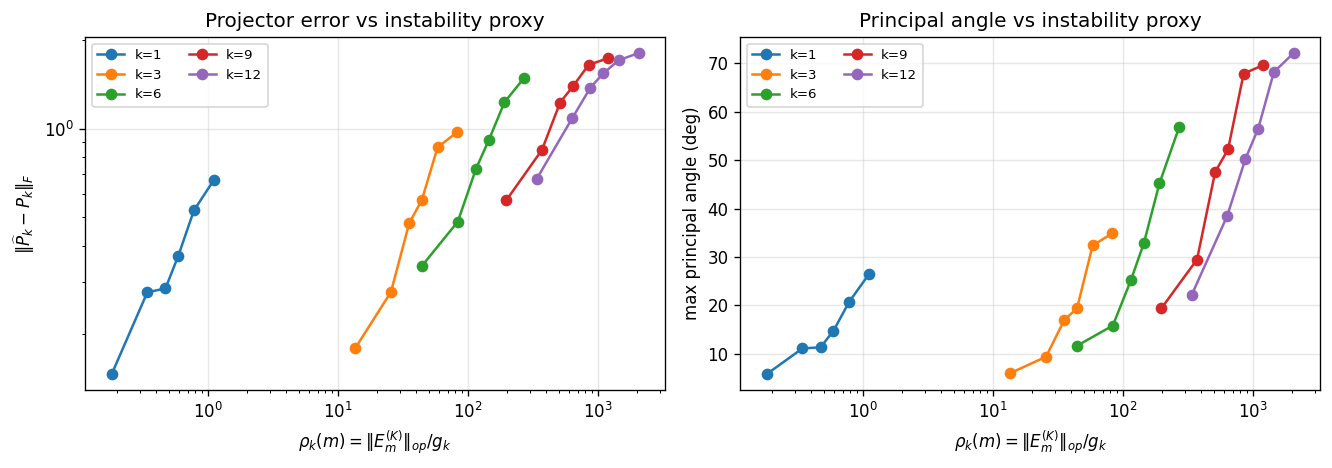

In [24]:
eps = 1e-12
rho = block_op_mean[:, None] / np.maximum(local_gap[None, :], eps)
max_angle_deg = np.degrees(np.nanmax(principal_angles_mean, axis=2))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0))
for k in [1, 3, 6, 9, 12]:
    if k in frequencies:
        i = fidx(k)
        axes[0].plot(rho[:, i], projector_fro_mean[:, i], 'o-', label=f'k={k}')
        axes[1].plot(rho[:, i], max_angle_deg[:, i], 'o-', label=f'k={k}')

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_xscale('log')
axes[0].set_xlabel(r'$\rho_k(m)=\|E_m^{(K)}\|_{op}/g_k$')
axes[1].set_xlabel(r'$\rho_k(m)=\|E_m^{(K)}\|_{op}/g_k$')
axes[0].set_ylabel(r'$\|\widehat P_k-P_k\|_F$')
axes[1].set_ylabel('max principal angle (deg)')
axes[0].set_title('Projector error vs instability proxy')
axes[1].set_title('Principal angle vs instability proxy')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

fig.tight_layout()
fig.savefig(PLOT_DIR / '02b_instability_proxy_vs_subspace_error.png', bbox_inches='tight')
plt.show()


## B3) Block perturbation concentration

We track global perturbation magnitude via
$$\|B_m^{(K)}-\Lambda_K\|_{max},\;\|\cdot\|_F,\;\|\cdot\|_{op}$$
against width.

Approximate $m^{-1/2}$ decay indicates concentration in width and sets the global error scale for frozen-mode predictions.


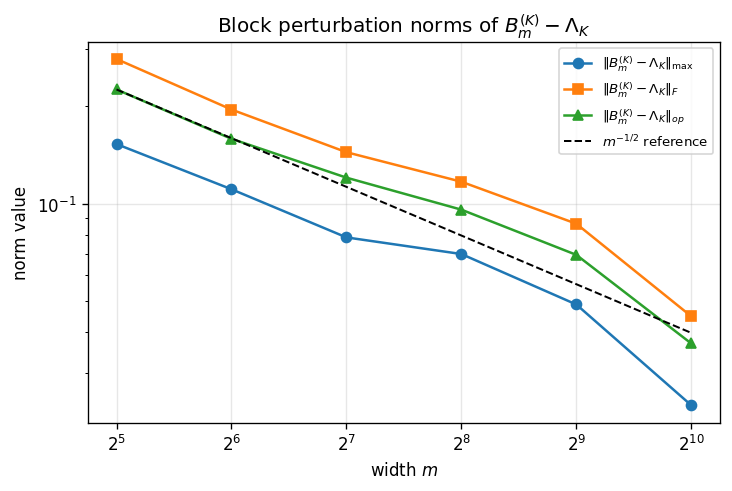

In [25]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(widths, block_max_mean, 'o-', label=r'$\|B_m^{(K)}-\Lambda_K\|_{\max}$')
ax.plot(widths, block_fro_mean, 's-', label=r'$\|B_m^{(K)}-\Lambda_K\|_{F}$')
ax.plot(widths, block_op_mean, '^-', label=r'$\|B_m^{(K)}-\Lambda_K\|_{op}$')

ref = block_op_mean[0] * (widths / widths[0]) ** (-0.5)
ax.plot(widths, ref, '--', c='k', lw=1.2, label=r'$m^{-1/2}$ reference')

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('width $m$')
ax.set_ylabel('norm value')
ax.set_title(r'Block perturbation norms of $B_m^{(K)}-\Lambda_K$')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PLOT_DIR / '03_block_perturbation_norms.png', bbox_inches='tight')
plt.show()


## B4) Frequency leakage and subspace fit

For each frequency block we compare on-block mass and off-block leakage mass under $B_m^{(K)}$.
Relative leakage is

$$\text{leakage}_k = \frac{\text{off-block mass}_k}{\max(\text{on-block mass}_k,\varepsilon)}.$$

We view leakage alongside projector error to connect operator mixing with subspace mismatch.


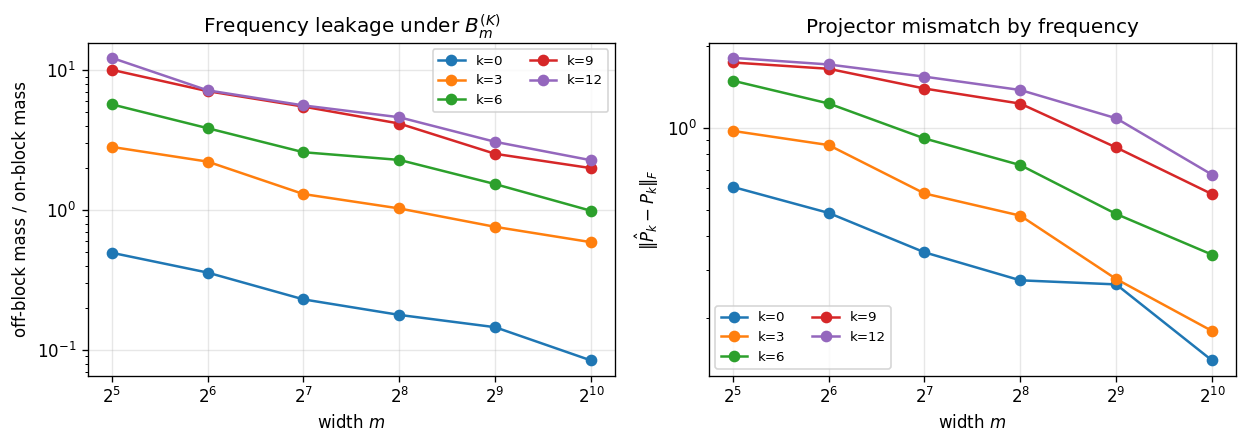

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for k in [0, 3, 6, 9, 12]:
    if k in frequencies:
        idx = int(np.where(frequencies == k)[0][0])
        axes[0].plot(widths, relative_leakage_mean[:, idx], 'o-', label=f'k={k}')
        axes[1].plot(widths, projector_fro_mean[:, idx], 'o-', label=f'k={k}')

axes[0].set_title('Frequency leakage under $B_m^{(K)}$')
axes[0].set_ylabel(r'off-block mass / on-block mass')
axes[1].set_title('Projector mismatch by frequency')
axes[1].set_ylabel(r'$\|\hat P_k - P_k\|_F$')

for ax in axes:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('width $m$')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

fig.tight_layout()
fig.savefig(PLOT_DIR / '04_leakage_and_projector_error.png', bbox_inches='tight')
plt.show()


## B5) Target-dependent reliability

For each support/target $S$ we report:

- target action error $\|(B_m^{(K)}-\Lambda_K)c_S\|/\|\Lambda_K c_S\|$,
- worst-case ratio $\|B_m^{(K)}-\Lambda_K\|_{op}/\lambda_{\min,S}$,
- support maxima of projector/relative-center/leakage diagnostics.

This is the core support-vs-width reliability view: low supports should cross thresholds earlier than high supports.


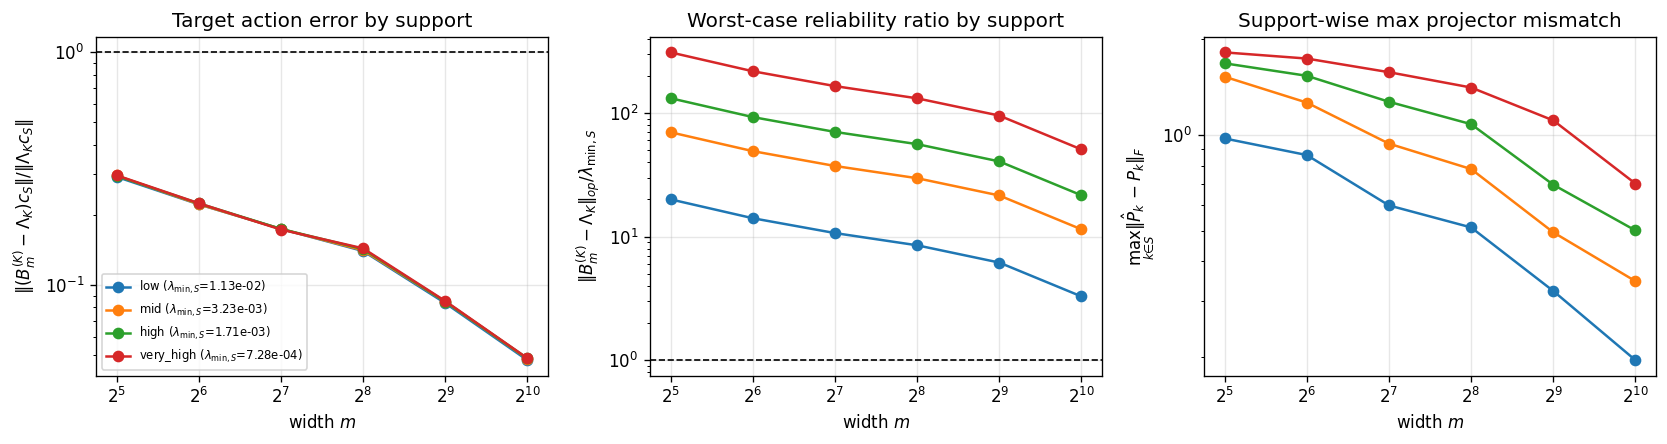

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 3.8))
for s_idx, name in enumerate(support_names):
    label = f'{name} ($\lambda_{{\min,S}}$={support_lambda_min[s_idx]:.2e})'
    axes[0].plot(widths, target_prediction_error_mean[:, s_idx], 'o-', label=label)
    axes[1].plot(widths, reliability_ratio_mean[:, s_idx], 'o-', label=label)
    axes[2].plot(widths, support_max_projector_fro_mean[:, s_idx], 'o-', label=name)

axes[0].axhline(tau, ls='--', c='k', lw=1.0)
axes[1].axhline(tau, ls='--', c='k', lw=1.0)

axes[0].set_title('Target action error by support')
axes[1].set_title('Worst-case reliability ratio by support')
axes[2].set_title('Support-wise max projector mismatch')
axes[0].set_ylabel(r'$\|(B_m^{(K)}-\Lambda_K)c_S\|/\|\Lambda_K c_S\|$')
axes[1].set_ylabel(r'$\|B_m^{(K)}-\Lambda_K\|_{op}/\lambda_{\min,S}$')
axes[2].set_ylabel(r'$\max_{k\in S}\|\hat P_k - P_k\|_F$')

for ax in axes:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('width $m$')
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(PLOT_DIR / '05_target_reliability.png', bbox_inches='tight')
plt.show()


In [23]:
summary_rows = []
for s_idx, name in enumerate(support_names):
    ok_target = np.where(target_prediction_error_mean[:, s_idx] <= tau)[0]
    ok_worst = np.where(reliability_ratio_mean[:, s_idx] <= tau)[0]
    w_target = None if len(ok_target) == 0 else int(widths[int(ok_target[0])])
    w_worst = None if len(ok_worst) == 0 else int(widths[int(ok_worst[0])])
    summary_rows.append((str(name), w_target, w_worst))

print('Minimum width achieving threshold tau =', tau)
print('(support, by target-error, by worst-case ratio)')
for row in summary_rows:
    print(row)

Minimum width achieving threshold tau = 1.0
(support, by target-error, by worst-case ratio)
('low', 32, None)
('mid', 32, None)
('high', 32, None)
('very_high', 32, None)


## Combined Takeaway

The story is relative, not absolute:

- Absolute perturbation $\|E_m^{(K)}\|$ shrinks with width (concentration).
- Frequency fragility is controlled by separation scale $g_k$ (gap-normalized instability).
- Target fragility is controlled by $\lambda_{\min,S}$ through
  $\|E_m^{(K)}\|_{op}/\lambda_{\min,S}$.

So the same width may already be reliable for low supports but still unreliable for higher-frequency supports.
